In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
%matplotlib inline
import os
import json
from typing import List, Tuple, Dict, Any
import functools
import copy

import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import spsa
from pennylane.transforms import transform

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [17]:
# set fixed seed to reproduce results
np.random.seed(42)

In [18]:
qml.about()

Name: PennyLane
Version: 0.40.0
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: https://github.com/PennyLaneAI/pennylane
Author: 
Author-email: 
License: Apache License 2.0
Location: /home/pta0054/it4i/qvsm/venv/lib/python3.10/site-packages
Requires: appdirs, autograd, autoray, cachetools, diastatic-malt, networkx, numpy, packaging, pennylane-lightning, requests, rustworkx, scipy, tomlkit, typing-extensions
Required-by: PennyLane-qiskit, PennyLane_Lightning

Platform info:           Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
Python version:          3.10.12
Numpy version:           2.0.2
Scipy version:           1.15.1
Installed devices:
- qiskit.aer (PennyLane-qiskit-0.40.0)
- qiskit.basicaer (PennyLane-qiskit-0.40.0)
- qiskit.basicsim (PennyLane-qiskit-0.40.0)
- qiskit.remote (PennyLane-qiskit-0.40.0)
- default.clifford 

In [19]:
DEBUG = False

# Definitions

In [20]:
def load_data(input_file: str, header: List[str] = []) -> pd.DataFrame:
    if header:
        df = pd.read_csv(input_file, names=header)
    else:
        df = pd.read_csv(input_file)
    return df

def preprocess_data(df: pd.DataFrame, y_mapping: Dict[Any, Any], y_column: str, PCA_number_of_components: int) -> Tuple[Tuple[np.ndarray, pd.Series], Tuple[np.ndarray, pd.Series]]:
    # Features (X) and target (y)
    X = df.drop(columns=y_column)  # features (all columns except target)
    y = df[y_column]               # target/class feature
    
    # scaling the labels to -1, 1 is important for the SVM and the definition of a hinge loss
    y = y.map(y_mapping)

    # Split the dataset: 80% training, 20% testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print("Train set size:", X_train.shape)
    print("Test set size:", X_test.shape)

    ## --- Scale Data --- ## 
    # Initialize the scaler
    scaler = StandardScaler()
    
    # Fit the scaler on training data, transform both training and testing data
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("--- Mean Scaler ---")
    print("Mean of scaled features (should be ~0):", np.mean(X_train_scaled, axis=0))
    print("Std of scaled features (should be ~1):", np.std(X_train_scaled, axis=0))
    print()
    
    # Initialize PCA to reduce to 2 principal components
    pca = PCA(n_components=PCA_number_of_components)
    
    # Fit PCA on the *scaled* training data and transform both train/test sets
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    print("--- PCA ---")
    print("Train set size after PCA:", X_train_pca.shape)
    print("Test set size after PCA:", X_test_pca.shape)
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Total variance explained by 2 components:", sum(pca.explained_variance_ratio_))
    print()
    
    # Visualize the obtained components
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.6)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA Projection (2D)')
    plt.colorbar(label='Target')
    plt.show()

    # Initialize MinMaxScaler to scale features between 0 and 1
    minmax_scaler = MinMaxScaler()
    
    # Fit on PCA-transformed training data and transform both train/test
    X_train_final = minmax_scaler.fit_transform(X_train_pca)
    X_test_final = minmax_scaler.transform(X_test_pca)

    print("--- Min-Max Scaler ---")
    print("Min value per feature (should be 0):", X_train_final.min(axis=0))
    print("Max value per feature (should be 1):", X_train_final.max(axis=0))
    print()

    # make non trainable
    X_train_final = np.array(X_train_final, requires_grad=False)
    X_test_final = np.array(X_test_final, requires_grad=False)
    y_train = np.array(y_train, requires_grad=False)
    y_test = np.array(y_test, requires_grad=False)

    return ((X_train_final, y_train), (X_test_final, y_test))

# Hyperparameters setting

In [21]:
n_qubits = 3
n_reps_fm = 1
n_reps_ansatz = 2
data_reupload = "Full" # Full, Partial(default)
dataset = "C"


In [22]:
trained_on_model = 3
version = 4
weights_file = f"w_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v{version}.npy"
results_file = f"r_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v{version}.csv"
training_history_file = f"h_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v{version}.json"
training_history_plot_file = f"h_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v{version}.pdf"

# Dataset loading

In [23]:
# Choose dataset

# A, Heart Failure Prediction
if dataset == "A":
    print(f"Chosen dataset: A, Heart Failure Prediction")
    df = load_data(os.path.join("datasets", "Heart Failure Prediction", "heart_failure_clinical_records_dataset.csv"))
# B, Pima Indians Diabetes Database
elif dataset == "B":
    print(f"Chosen dataset: B, Pima Indians Diabetes Database")
    df = load_data(os.path.join("datasets", "Pima Indians Diabetes Database", "diabetes.csv"))
# C, Breast Cancer Wisconsin
elif dataset == "C":
    print(f"Chosen dataset: C, Breast Cancer Wisconsin")
    df = load_data(os.path.join("datasets", "Breast Cancer Wisconsin (Diagnostic)", "wdbc.data"), header=["id","diagnosis","radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean","radius_se","texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave points_se","symmetry_se","fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst",])
else:
    raise Exception(f"Unknown dataset: {dataset}")

print(f"Dataframe shape: {df.shape}")
df.head()

Chosen dataset: C, Breast Cancer Wisconsin
Dataframe shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [24]:
if dataset == "A":
    print(f"Targets: {df['DEATH_EVENT'].unique()}")
# B, Pima Indians Diabetes Database
elif dataset == "B":
    print(f"Targets: {df['Outcome'].unique()}")
# C, Breast Cancer Wisconsin
elif dataset == "C":
    print(f"Targets: {df['diagnosis'].unique()}")
else:
    raise Exception(f"Unknown dataset: {dataset}")

Targets: ['M' 'B']


Train set size: (455, 31)
Test set size: (114, 31)
--- Mean Scaler ---
Mean of scaled features (should be ~0): [ 0.00000000e+00 -3.16230558e-16 -3.51367287e-17 -1.13218348e-16
  3.66983611e-16 -2.38148939e-16 -4.29448906e-17 -5.95372347e-17
  2.22532615e-16  1.44450996e-16  5.05578485e-16  9.56499837e-17
  7.02734574e-17  2.83045870e-16  6.24652955e-17 -7.80816193e-18
 -1.52259158e-16  2.14724453e-17 -2.14724453e-16 -1.91299967e-16
  2.24484656e-16 -7.02734574e-17 -6.75406007e-16 -2.92806072e-17
  1.81539765e-16 -1.56163239e-17 -2.24972666e-16 -7.61295788e-17
 -8.19857003e-17  5.15338687e-16  2.14724453e-17]
Std of scaled features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1.]

--- PCA ---
Train set size after PCA: (455, 3)
Test set size after PCA: (114, 3)
Explained variance ratio: [0.42132688 0.18887304 0.09556973]
Total variance explained by 2 components: 0.7057696576239375



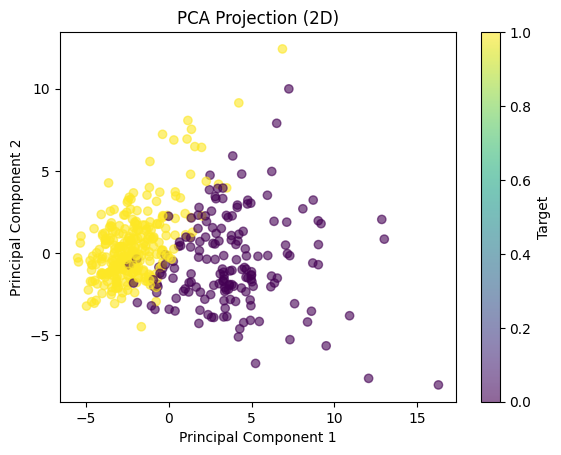

--- Min-Max Scaler ---
Min value per feature (should be 0): [0. 0. 0.]
Max value per feature (should be 1): [1. 1. 1.]



In [25]:
# Divide data into train and test split
# A,
if dataset == "A":
    (X_train, y_train), (X_test, y_test) = preprocess_data(df, y_mapping={1: 1, 0: 0}, y_column="DEATH_EVENT", PCA_number_of_components=n_qubits)
# B,
elif dataset == "B":
    (X_train, y_train), (X_test, y_test) = preprocess_data(df, y_mapping={1: 1, 0: 0}, y_column="Outcome", PCA_number_of_components=n_qubits)
# C,
elif dataset == "C":
    (X_train, y_train), (X_test, y_test) = preprocess_data(df, y_mapping={'M': 0, 'B': 1}, y_column="diagnosis", PCA_number_of_components=n_qubits)

In [26]:
# Take only some portion of data
each_nth = 1 # 1 = all data

X_train_sampled = X_train[::each_nth]
y_train_sampled = y_train[::each_nth]
X_test_sampled = X_test[::each_nth]
y_test_sampled = y_test[::each_nth]

print(f"Size of sampled dataset: {X_train_sampled.shape}. Fraction of the input dataset: {X_train_sampled.shape[0] / X_train.shape[0]}")

Size of sampled dataset: (455, 3). Fraction of the input dataset: 1.0


# Model definition and training

## Shared parts

In [27]:
#plot_history(loaded_history_per_epoch, output_file=training_history_plot_file + ".valids", ansatz_layers=n_reps_ansatz, fm_layers=n_reps_fm, n_shots=n_shots, n_qubits=n_qubits, dataset=dataset, data_reuploading=data_reupload)

In [28]:
# plot training cost and accuracy history - VALID VERSIONS
# def plot_history(history, ansatz_layers, fm_layers, n_shots, n_qubits, dataset, data_reuploading, output_file):
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

#     # --- First subplot with dual y-axes ---
#     ax1_loss = ax1
#     ax1_acc = ax1.twinx()  # create a second y-axis for accuracy
    
#     # Plot cost function (left y-axis)
#     ax1_loss.plot(history["train_loss"]["avg"], marker='o', linestyle='-', color='b', label='Cost function')
#     ax1_loss.set_ylabel('Train cost function value', color='b')
#     ax1_loss.tick_params(axis='y')
    
#     # Plot accuracy (right y-axis)
#     ax1_acc.plot(history["train_avg_scores"]["Accuracy"], marker='x', linestyle='--', color='g', label='Train accuracy')
#     ax1_acc.plot(history["train_avg_scores"]["Precision"], marker='s', linestyle='--', color='g', label='Train precision')
#     ax1_acc.plot(history["train_avg_scores"]["F1"], marker='^', linestyle='--', color='g', label='Train F1 score')
#     ax1_acc.set_ylabel('Train dataset metrics', color='g')
#     ax1_acc.tick_params(axis='y')
#     ax1_acc.set_ylim(0, 1)
    
#     # Title & legend
#     ax1_loss.set_title(f'Dataset={dataset}, Qubits={n_qubits}, Shots={n_shots}, Ansatz layers={ansatz_layers}, Feature map layers={fm_layers}, Data reuploading={data_reuploading}')
#     ax1_loss.grid(True)
#     #ax1_loss.set_ylim(3, None)
    
#     # If you want a combined legend from both axes
#     lines_loss, labels_loss = ax1_loss.get_legend_handles_labels()
#     lines_acc, labels_acc = ax1_acc.get_legend_handles_labels()
#     ax1_loss.legend(lines_loss + lines_acc, labels_loss + labels_acc, loc='lower right')

#     # Plot average number of repetitions on the second subplot
#     ax2.plot(history["train_valids"]["avg"], marker='s', linestyle='--', color='blue', label='Avg valid repetitions')
#     ax2.plot(history["train_valids"]["max"], marker='s', linestyle='--', color='red', label='Max valid repetitions')
#     ax2.plot(history["train_valids"]["min"], marker='s', linestyle='--', color='green', label='Min valid repetitions')

#     ax2.set_xlabel('Epoch')
#     ax2.set_ylabel('Number of repetitions statistics.')
#     ax2.legend(loc='upper right')
#     ax2.grid(True)

#     # Save the plot to a PDF
#     title = f"Training History, Qubits={n_qubits}, Shots={n_shots}, Ansatz layers={ansatz_layers}, Feature map layers={fm_layers}"
#     if os.path.exists(f'results/{output_file}'):
#         print(f"Path already exists")
#     else:
#         plt.savefig(f'results/{output_file}', format='pdf', bbox_inches='tight')
    
#     plt.tight_layout()
#     plt.show()

In [29]:
training_history_plot_file

'h_qubits=3_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=C_trained=3.v4.pdf'

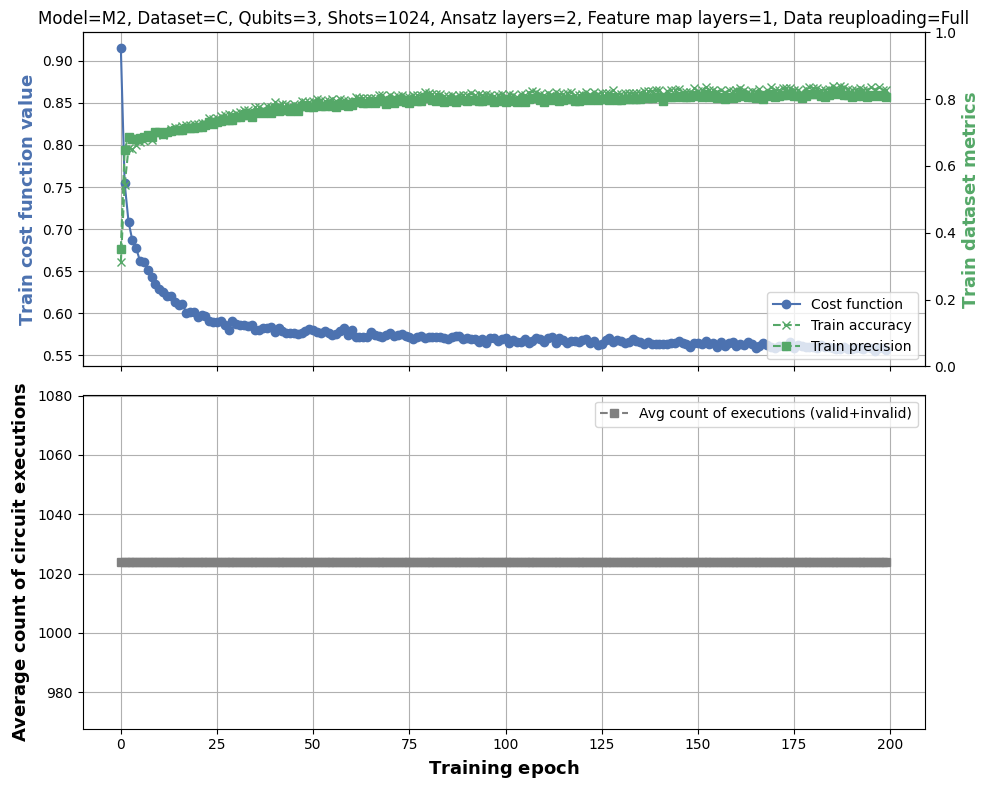

In [144]:
import matplotlib.pyplot as plt
plt.rcdefaults()

plot_history(loaded_history_per_epoch, output_file=training_history_plot_file, ansatz_layers=n_reps_ansatz, fm_layers=n_reps_fm, n_shots=1024, n_qubits=n_qubits, dataset=dataset, data_reuploading=data_reupload, model="M2")

In [126]:
loaded_history_per_epoch["train_invalids"]["avg"]

[66.74467418546365,
 76.50031328320802,
 87.11184210526316,
 88.8969298245614,
 91.13126566416041,
 90.9674185463659,
 92.01629072681705,
 90.70238095238096,
 90.83552631578948,
 92.52756892230576,
 94.25814536340852,
 95.08677944862156,
 94.9423558897243,
 96.078007518797,
 96.14943609022556,
 93.33427318295739,
 92.64285714285714,
 93.51535087719299,
 92.52506265664161,
 94.32832080200501,
 94.50438596491227,
 93.88001253132833,
 94.15444862155388,
 93.82111528822055,
 95.22901002506266,
 95.55670426065163,
 95.64880952380953,
 95.89912280701755,
 95.53822055137844,
 96.17763157894737,
 98.05576441102757,
 98.52506265664161,
 98.62781954887218,
 97.14630325814535,
 97.71585213032581,
 97.77725563909775,
 98.92512531328322,
 97.78508771929825,
 97.94830827067669,
 98.17261904761904,
 97.9718045112782,
 98.43577694235589,
 98.1516290726817,
 99.69548872180451,
 99.4655388471178,
 99.51002506265664,
 100.12531328320802,
 100.52286967418547,
 101.07926065162907,
 101.87437343358395,
 101

In [30]:
# Some shared definitions

# plot pennylane circuit
def draw_circuit(circuit, fontsize=20, style='pennylane', scale=None, title=None, decimals=2, level=None):
    def _draw_circuit(*args, **kwargs):
        nonlocal circuit, fontsize, style, scale, title, level
        qml.drawer.use_style(style)
        fig, ax = qml.draw_mpl(circuit, decimals=decimals, level=level)(*args, **kwargs)
        if scale is not None:
            dpi = fig.get_dpi()
            fig.set_dpi(dpi*scale)
        if title is not None:
            fig.suptitle(title, fontsize=fontsize)
        plt.show()
    return _draw_circuit
    
# plot training cost and accuracy history
def plot_history(history, ansatz_layers, fm_layers, n_shots, n_qubits, dataset, data_reuploading, output_file, model: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # --- First subplot with dual y-axes ---
    ax1_loss = ax1
    ax1_acc = ax1.twinx()  # create a second y-axis for accuracy
    
    # Plot cost function (left y-axis)
    ax1_loss.plot(history["train_loss"]["avg"], marker='o', linestyle='-', color='b', label='Cost function')
    ax1_loss.set_ylabel(r'$\bf{Train~cost~function~value}$', color='b', fontsize=13)
    ax1_loss.tick_params(axis='y')
    
    # Plot accuracy (right y-axis)
    ax1_acc.plot(history["train_avg_scores"]["Accuracy"], marker='x', linestyle='--', color='g', label='Train accuracy')
    ax1_acc.plot(history["train_avg_scores"]["Precision"], marker='s', linestyle='--', color='g', label='Train precision')
    #ax1_acc.plot(history["train_avg_scores"]["F1"], marker='^', linestyle='--', color='g', label='Train F1 score')
    ax1_acc.set_ylabel(r'$\bf{Train~dataset~metrics}$', color='g', fontsize=13)
    ax1_acc.tick_params(axis='y')
    ax1_acc.set_ylim(0, 1)
    
    # Title & legend
    ax1_loss.set_title(f'Model={model}, Dataset={dataset}, Qubits={n_qubits}, Shots={n_shots}, Ansatz layers={ansatz_layers}, Feature map layers={fm_layers}, Data reuploading={data_reuploading}')
    ax1_loss.grid(True)
    #ax1_loss.set_ylim(3, None)
    
    # If you want a combined legend from both axes
    lines_loss, labels_loss = ax1_loss.get_legend_handles_labels()
    lines_acc, labels_acc = ax1_acc.get_legend_handles_labels()
    ax1_loss.legend(lines_loss + lines_acc, labels_loss + labels_acc, loc='lower right')

    # Plot average number of repetitions on the second subplot{metric.split(' ')[0]} 
    if model == "M3":
        ax2.plot(history["train_valids"]["avg"], marker='s', linestyle='--', color='green', label='Avg count of executions (valid)')
        ax2.plot(history["train_invalids"]["avg"], marker='s', linestyle='--', color='red', label='Avg count of executions (invalid)')
        ax2.plot(history["train_exec"]["avg"], marker='s', linestyle='--', color='gray', label='Avg count of executions (valid+invalid)')
    else:
        ax2.plot(history["train_exec"]["avg"], marker='s', linestyle='--', color='gray', label='Avg count of executions (valid+invalid)')


    ax2.set_xlabel(r'$\bf{Training~epoch}$', fontsize=13)
    ax2.set_ylabel(r'$\bf{Average~count~of~circuit~executions}$', fontsize=13)

    # ax2.set_yscale("log")
    # ax2.set_ylim([1, 1628])
    ax2.legend(loc='upper right')
    ax2.grid(True)

    # Save the plot to a PDF
    title = f"Training History, Qubits={n_qubits}, Shots={n_shots}, Ansatz layers={ansatz_layers}, Feature map layers={fm_layers}"
    if os.path.exists(f'results/{output_file}'):
        print(f"Path already exists: results/{output_file}")
    else:
        plt.savefig(f'results/{output_file}', format='pdf', bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()

In [118]:
loaded_history_per_epoch["train_exec"].keys()

dict_keys(['avg', 'min', 'max'])

In [31]:
# Build the feature map and ansatz
def zz_feature_map(x):
    for _ in range(n_reps_fm):
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
            qml.PhaseShift(2.0 * x[..., i], wires=i)
        # LINEAR entanglement
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
            qml.PhaseShift(2.0 * (np.pi - x[..., i]) * (np.pi - x[..., i+1]), wires=i+1)
            qml.CNOT(wires=[i, i+1])
        qml.Barrier()


def ansatz_real_amplitudes(weights, _):
    # Initial encoding + rotations
    for j in range(n_qubits):
            qml.RY(weights[0, j], wires=j)

    # Repeated layers
    for i in range(n_reps_ansatz):
        # Entanglement: reverse-linear
        for j in range(n_qubits - 1, 0, -1):
            qml.CNOT(wires=[j - 1, j])
        for j in range(n_qubits):
            qml.RY(weights[i+1, j], wires=j)
        qml.Barrier()

def ansatz_real_amplitudes_full_reuploading(weights, x):
    # Initial encoding + rotations
    for j in range(n_qubits):
        qml.RY(weights[0, j], wires=j)  # data re-uploaded in angle
    
    # Repeated layers
    for i in range(n_reps_ansatz):
        # Data reuploading
        for j in range(n_qubits):
            qml.RY(x[..., j], wires=j)
        
        # Entanglement: reverse-linear
        for j in range(n_qubits - 1, 0, -1):
            qml.CNOT(wires=[j - 1, j])
    
        # Trainable rotations
        for j in range(n_qubits):
            qml.RY(weights[i + 1, j], wires=j)
        
        qml.Barrier()

# Choose version of ansatz
if data_reupload == "Full":
    ansatz = ansatz_real_amplitudes_full_reuploading
else:
    ansatz = ansatz_real_amplitudes

In [32]:
@transform
def add_noise(tape, p_depol=0.01, p_amp=0.02, p_phase=0.02):
    """Adds noise channels after each gate (per wire)."""
    new_ops = []

    for op in tape.operations:
        new_ops.append(op)
        for w in op.wires:
            new_ops.append(qml.DepolarizingChannel(p_depol, wires=w))
            new_ops.append(qml.AmplitudeDamping(p_amp, wires=w))
            new_ops.append(qml.PhaseDamping(p_phase, wires=w))

    new_tape = qml.tape.QuantumScript(new_ops, tape.measurements)
    
    # Return a tuple: list of tapes + processing function
    return [new_tape], lambda results: results

In [33]:
# Input and random weights
init_params = np.random.uniform(0, 2 * np.pi, (n_reps_ansatz + 1, n_qubits), requires_grad=True)
print(f"Shape of weights: {init_params.shape}")
print(f"Count of weights: {init_params.size}")
print(f"Initial weights:\n{init_params}")

Shape of weights: (3, 3)
Count of weights: 9
Initial weights:
[[2.35330497 5.97351416 4.59925358]
 [3.76148219 0.98029403 0.98014248]
 [0.3649501  5.44234523 3.77691701]]


## Definitions of model parts

### Non-vectorized

In [34]:
def get_metrics(X, y_true, trained_weights, forward_func, show = False):
    y_preds_list = []
    y_probs_list = []
    n_executions_list = []
    n_valids_list = []
    n_invalids_list = []
    forward_times_list = []
    
    start_all = time.perf_counter()
    #print("y_true:", y_true)
    for i in range(len(X)):
        start_forward = time.perf_counter()
        y_scores, y_pred, stats = forward_func(X[i], trained_weights)
        end_forward = time.perf_counter()

        #print("y_pred:", y_pred)
        # Map to probability of class +1 using sigmoid
        #y_prob = 1 / (1 + np.exp(-y_pred))  # sigmoid mapping of raw [-3,3] values
        # Total votes
        total = len(y_pred)
        
        # Probability for each class
        class_1_cnt = sum(y_pred == 1)
        class_0_cnt = sum(y_pred == -1)
        
        prob_1 = class_1_cnt / total
        prob_0 = class_0_cnt / total
        #print("y_prob:", y_prob)

        # classify
        y_pred = 1 if prob_1 >= prob_0 else 0
        #print("y_pred:", y_pred, "\n")

        y_preds_list.append(y_pred)
        y_probs_list.append(prob_1)
        n_executions_list.append(stats["n_executions"])
        n_valids_list.append(stats["n_valids"])
        n_invalids_list.append(stats["n_invalids"])
        forward_times_list.append(end_forward - start_forward)
        
    end_all = time.perf_counter()
    time_elapsed_all = end_all - start_all
    time_elapsed_forward_min = np.min(forward_times_list)
    time_elapsed_forward_avg = np.mean(forward_times_list)
    time_elapsed_forward_max = np.max(forward_times_list)
    
    # Compute metrics
    accuracy = accuracy_score(y_true, y_preds_list)
    precision = precision_score(y_true, y_preds_list)
    recall = recall_score(y_true, y_preds_list)
    f1 = f1_score(y_true, y_preds_list)
    roc_auc = roc_auc_score(y_true, y_probs_list)
    # Number of executions
    min_num_of_exec = np.min(n_executions_list)
    max_num_of_exec = np.max(n_executions_list)
    avg_num_of_exec = np.mean(n_executions_list)
    # number of valids
    min_num_of_valid = np.min(n_valids_list)
    avg_num_of_valid = np.mean(n_valids_list)
    max_num_of_valid = np.max(n_valids_list)
    # number of invalids
    min_num_of_invalid = np.min(n_invalids_list)
    avg_num_of_invalid = np.mean(n_invalids_list)
    max_num_of_invalid = np.max(n_invalids_list)

    
    # Print results
    if show:
        print(f"Accuracy                         : {accuracy:.4f}")
        print(f"Precision                        : {precision:.4f}")
        print(f"Recall                           : {recall:.4f}")
        print(f"F1 Score                         : {f1:.4f}")
        print(f"ROC AUC                          : {roc_auc:.4f}")
        print(f"Min/Avg/Max # of executions      : {int(min_num_of_exec)}/{avg_num_of_exec:.4f}/{int(max_num_of_exec)}")
        print(f"Min/Avg/Max # of valids          : {int(min_num_of_valid)}/{avg_num_of_valid:.4f}/{int(max_num_of_valid)}")
        print(f"Min/Avg/Max # of invalids        : {int(min_num_of_invalid)}/{avg_num_of_invalid:.4f}/{int(max_num_of_invalid)}")

        print(f"Classification time elapsed      : {time_elapsed_all}s ")
        print(f"Min/Avg/Max forward time elapsed : {time_elapsed_forward_min}/{time_elapsed_forward_avg}/{time_elapsed_forward_max}")

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1, "ROC AUC": roc_auc, 
            "Min number of executions": min_num_of_exec, "Avg number of executions": avg_num_of_exec, "Max number of executions": max_num_of_exec,
            "Min number of valids": min_num_of_valid, "Avg number of valids": avg_num_of_valid, "Max number of valids": max_num_of_valid,
            "Min number of invalids": min_num_of_invalid, "Avg number of invalids": avg_num_of_invalid, "Max number of invalids": max_num_of_invalid,
            "Classification time[s]": time_elapsed_all, "Min time per forward pass[s]": time_elapsed_forward_min, "Avg time per forward pass[s]": time_elapsed_forward_avg,
            "Max time per forward pass[s]": time_elapsed_forward_max}

#get_metrics(X_train_sampled, y_train_sampled, init_params, one_shot_hamming_unambiqous_qvc_forward, show=True)

#### Model 1

In [19]:
def many_shots_default_distance_interpret_bitstring(exp_vals: List[int]) -> List[int]:
    #print("exp_vals: ", exp_vals)
    # go through all output bitstrings from every shot
    
    interpreted_values = np.sign(exp_vals)
   
    return interpreted_values


In [20]:
def many_shots_default_qvc_forward(x, weights):
    n_executions = n_shots
    n_valid = n_shots
    n_invalid = 0
    
    raw_values = np.array(many_shots_default_qvc_circuit(x, weights)).T  # shape: (shots, n_qubits)
    
    interpreted_values: np.array = many_shots_default_distance_interpret_bitstring(raw_values)

    return raw_values, interpreted_values,  {"n_executions": n_executions, "n_valids": n_valid, "n_invalids": n_invalid}
    
#many_shots_default_qvc_forward(X_train_sampled[0], init_params)

In [21]:
def many_shots_default_loss_fn(weights, x, y_true,  eps: float = 1e-9):
    raw_values, interpreted_values, stats = many_shots_default_qvc_forward(x, weights)

    raw_score = np.mean(raw_values)
    prob = 1 / (1 + np.exp(-raw_score))
    loss = -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))

    if DEBUG:
        print("y_true= ", y_true)
        print("raw_value_valid : interpreted_value_valid")
        for i in range(min(10, len(raw_values))):
            print(raw_values[i], " : ", interpreted_values[i])
        print("raw_score= ", raw_score)
        print("prob= ", prob)
        print("loss= ", loss)

    return loss, stats
    
#many_shots_default_loss_fn(init_params, X_train_sampled[0], y_train_sampled[0])

In [22]:
def many_shots_default_train_qnn(X_train, y_train, params, loss_fn, opt, epochs=20, batch_size=32):
    n_samples = len(X_train)

    best_params = params
    best_loss = np.inf  # Initialize to infinity

    history_per_batch = {
        "train_exec": {"avg": [], "min": [], "max": []},
        "train_valids": {"avg": [], "min": [], "max": []},
        "train_invalids": {"avg": [], "min": [], "max": []},
        "train_loss": {"avg": []}
    }
    history_per_epoch = {"train_exec": {"avg": [], "min": [], "max": []},
                         "train_valids": {"avg": [], "min": [], "max": []},
                         "train_invalids": {"avg": [], "min": [], "max": []},
                         "train_loss": {"avg": []}, 
                         "train_avg_scores": {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC AUC": [], 
                                              "Min number of executions": [], "Avg number of executions": [], "Max number of executions": [],
                                              'Min number of valids': [], 'Avg number of valids': [], 'Max number of valids': [],
                                              'Min number of invalids': [], 'Avg number of invalids': [], 'Max number of invalids': [],
                                              "Classification time[s]": [], "Min time per forward pass[s]": [], "Avg time per forward pass[s]": [],
                                              "Max time per forward pass[s]": []}}    # Batch loss function

    # Batch loss function
    def batch_loss(w):
        #losses = []
        n_executions = []
        n_valids = [] 
        n_invalids = []
        avg_loss = 0
        for x, y in zip(X_batch, y_batch):
            l, stats = loss_fn(w, x, y)
            avg_loss += l
            #losses.append(l)
            n_executions.append(stats["n_executions"])
            n_valids.append(stats["n_valids"])
            n_invalids.append(stats["n_invalids"])

        avg_loss = avg_loss / batch_size
        # train execs
        history_per_batch["train_exec"]["avg"].append(np.mean(n_executions))
        history_per_batch["train_exec"]["min"].append(np.min(n_executions))
        history_per_batch["train_exec"]["max"].append(np.max(n_executions))
        # train valids
        history_per_batch["train_valids"]["avg"].append(np.mean(n_valids))
        history_per_batch["train_valids"]["min"].append(np.min(n_valids))
        history_per_batch["train_valids"]["max"].append(np.max(n_valids))
        # train invalids
        history_per_batch["train_invalids"]["avg"].append(np.mean(n_invalids))
        history_per_batch["train_invalids"]["min"].append(np.min(n_invalids))
        history_per_batch["train_invalids"]["max"].append(np.max(n_invalids))
        
        history_per_batch["train_loss"]["avg"].append(qml.math.toarray(avg_loss))
        return avg_loss

    try:
        for epoch in range(epochs):
            # Shuffle data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            total_loss_epoch = 0
            
            total_execs_epoch = 0
            min_execs_epoch = max_executions
            max_execs_epoch = 0

            total_valids_epoch = 0
            min_valids_epoch = max_executions
            max_valids_epoch = 0

            total_invalids_epoch = 0
            min_invalids_epoch = max_executions
            max_invalids_epoch = 0
            
            num_batches = int(np.ceil(n_samples / batch_size))
    
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i+batch_size]
                y_batch = y_shuffled[i: i+batch_size]
    
                params = opt.step(batch_loss, params)
                total_loss_epoch += history_per_batch["train_loss"]["avg"][-1]
                total_execs_epoch += history_per_batch["train_exec"]["avg"][-1]
                min_execs_epoch = min(min_execs_epoch, history_per_batch["train_exec"]["min"][-1])
                max_execs_epoch = max(max_execs_epoch, history_per_batch["train_exec"]["max"][-1])

                total_valids_epoch += history_per_batch["train_valids"]["avg"][-1]
                min_valids_epoch = min(min_valids_epoch, history_per_batch["train_valids"]["min"][-1])
                max_valids_epoch = max(max_valids_epoch, history_per_batch["train_valids"]["max"][-1])

                total_invalids_epoch += history_per_batch["train_invalids"]["avg"][-1]
                min_invalids_epoch = min(min_invalids_epoch, history_per_batch["train_invalids"]["min"][-1])
                max_invalids_epoch = max(max_invalids_epoch, history_per_batch["train_invalids"]["max"][-1])
    
            avg_loss_per_epoch = total_loss_epoch / num_batches
            avg_execs_per_epoch = total_execs_epoch / num_batches
            avg_valids_per_epoch = total_valids_epoch / num_batches
            avg_invalids_per_epoch = total_invalids_epoch / num_batches
            history_per_epoch["train_loss"]["avg"].append(avg_loss_per_epoch)
            history_per_epoch["train_exec"]["avg"].append(avg_execs_per_epoch)
            history_per_epoch["train_exec"]["min"].append(min_execs_epoch)
            history_per_epoch["train_exec"]["max"].append(max_execs_epoch)
            history_per_epoch["train_valids"]["avg"].append(avg_valids_per_epoch)
            history_per_epoch["train_valids"]["min"].append(min_valids_epoch)
            history_per_epoch["train_valids"]["max"].append(max_valids_epoch)
            history_per_epoch["train_invalids"]["avg"].append(avg_invalids_per_epoch)
            history_per_epoch["train_invalids"]["min"].append(min_invalids_epoch)
            history_per_epoch["train_invalids"]["max"].append(max_invalids_epoch)
            
            # calculate epoch accuracy on train data
            metrics_per_epoch = get_metrics(X_train, y_train, params, forward_func=many_shots_default_qvc_forward)
            # print progress
            print(f"Epoch {epoch + 1}")
            print(f"\tAvg train Loss            : {avg_loss_per_epoch:.4f}")
            print(f"\tMin/Avg/Max train # of executions : {int(min_execs_epoch)}/{avg_execs_per_epoch:.4f}/{int(max_execs_epoch)}")
            for score_name in metrics_per_epoch.keys():
                history_per_epoch["train_avg_scores"][score_name].append(metrics_per_epoch[score_name])
                print(f"\tTrain {score_name}\t: {metrics_per_epoch[score_name]:.4f}")
            
            # Save best parameters
            if avg_loss_per_epoch < best_loss:
                best_loss = avg_loss_per_epoch
                best_params = params.copy()  # Make a copy to freeze the best values
    except KeyboardInterrupt:
        print("\nOptimization interrupted! Returning best parameters found so far:")
            
    return best_params, history_per_batch, history_per_epoch

# params = init_params.copy()
# epochs = 50
# batch_size = 8
# opt = qml.RMSPropOptimizer(stepsize=0.1, decay=0.7, eps=1e-08)
# trained_weights, history_per_batch, history_per_epoch = many_shots_default_train_qnn(X_train_sampled, y_train_sampled, opt=opt, loss_fn=many_shots_default_loss_fn, params=params, epochs=epochs, batch_size=batch_size)

#### Model 2

In [23]:
def many_shots_humming_distance_interpret_bitstring(exp_vals) -> List[int]:
    #print("exp_vals: ", exp_vals)
    # go through all output bitstrings from every shot
    summed = np.sum(exp_vals, axis=1)
    
    interpreted_values = np.sign(summed)
   
    return interpreted_values

In [24]:
def many_shots_hamming_qvc_forward(x, weights):
    n_executions = n_shots
    n_valid = n_shots
    n_invalid = 0
    
    raw_values = np.array(many_shots_hamming_qvc_circuit(x, weights)).T  # shape: (shots, n_qubits)
    interpreted_values: np.array = many_shots_humming_distance_interpret_bitstring(raw_values)

    return raw_values, interpreted_values,  {"n_executions": n_executions, "n_valids": n_valid, "n_invalids": n_invalid}

#many_shots_hamming_qvc_forward(X_train_sampled[0], init_params)

In [25]:
def many_shots_hamming_loss_fn(weights, x, y_true, eps: float = 1e-9):
    raw_values, interpreted_values, stats = many_shots_hamming_qvc_forward(x, weights)

    raw_score = np.mean(np.sum(raw_values, axis=1))
    prob = 1 / (1 + np.exp(-raw_score))
    loss = -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))

    if DEBUG:
        print("y_true= ", y_true)
        print("raw_value_valid : interpreted_value_valid")
        for i in range(min(10, len(raw_values_valid))):
            print(raw_values_valid[i], " : ", interpreted_values_valid[i])
        print("raw_score= ", raw_score)
        print("prob= ", prob)
        print("loss= ", loss)

    return loss, stats
    
#many_shots_hamming_loss_fn(init_params, X_train_sampled[0], y_train_sampled[0])

In [26]:
def many_shots_hamming_train_qnn(X_train, y_train, params, loss_fn, opt, epochs=20, batch_size=32):
    n_samples = len(X_train)

    best_params = params
    best_loss = np.inf  # Initialize to infinity

    history_per_batch = {
        "train_exec": {"avg": [], "min": [], "max": []},
        "train_valids": {"avg": [], "min": [], "max": []},
        "train_invalids": {"avg": [], "min": [], "max": []},
        "train_loss": {"avg": []}
    }
    history_per_epoch = {"train_exec": {"avg": [], "min": [], "max": []},
                         "train_valids": {"avg": [], "min": [], "max": []},
                         "train_invalids": {"avg": [], "min": [], "max": []},
                         "train_loss": {"avg": []}, 
                         "train_avg_scores": {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC AUC": [], 
                                              "Min number of executions": [], "Avg number of executions": [], "Max number of executions": [],
                                              'Min number of valids': [], 'Avg number of valids': [], 'Max number of valids': [],
                                              'Min number of invalids': [], 'Avg number of invalids': [], 'Max number of invalids': [],
                                              "Classification time[s]": [], "Min time per forward pass[s]": [], "Avg time per forward pass[s]": [],
                                              "Max time per forward pass[s]": []}}    # Batch loss function
    def batch_loss(w):
        #losses = []
        n_executions = []
        n_valids = [] 
        n_invalids = []
        avg_loss = 0
        for x, y in zip(X_batch, y_batch):
            l, stats = loss_fn(w, x, y)
            avg_loss += l
            #losses.append(l)
            n_executions.append(stats["n_executions"])
            n_valids.append(stats["n_valids"])
            n_invalids.append(stats["n_invalids"])
        avg_loss = avg_loss / batch_size
        # train execs
        history_per_batch["train_exec"]["avg"].append(np.mean(n_executions))
        history_per_batch["train_exec"]["min"].append(np.min(n_executions))
        history_per_batch["train_exec"]["max"].append(np.max(n_executions))
        # train valids
        history_per_batch["train_valids"]["avg"].append(np.mean(n_valids))
        history_per_batch["train_valids"]["min"].append(np.min(n_valids))
        history_per_batch["train_valids"]["max"].append(np.max(n_valids))
        # train invalids
        history_per_batch["train_invalids"]["avg"].append(np.mean(n_invalids))
        history_per_batch["train_invalids"]["min"].append(np.min(n_invalids))
        history_per_batch["train_invalids"]["max"].append(np.max(n_invalids))
        
        history_per_batch["train_loss"]["avg"].append(qml.math.toarray(avg_loss))
        return avg_loss

    try:
        for epoch in range(epochs):
            # Shuffle data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            total_loss_epoch = 0
            
            total_execs_epoch = 0
            min_execs_epoch = max_executions
            max_execs_epoch = 0

            total_valids_epoch = 0
            min_valids_epoch = max_executions
            max_valids_epoch = 0

            total_invalids_epoch = 0
            min_invalids_epoch = max_executions
            max_invalids_epoch = 0
            
            num_batches = int(np.ceil(n_samples / batch_size))
    
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i+batch_size]
                y_batch = y_shuffled[i: i+batch_size]
    
                params = opt.step(batch_loss, params)
                total_loss_epoch += history_per_batch["train_loss"]["avg"][-1]
                total_execs_epoch += history_per_batch["train_exec"]["avg"][-1]
                min_execs_epoch = min(min_execs_epoch, history_per_batch["train_exec"]["min"][-1])
                max_execs_epoch = max(max_execs_epoch, history_per_batch["train_exec"]["max"][-1])

                total_valids_epoch += history_per_batch["train_valids"]["avg"][-1]
                min_valids_epoch = min(min_valids_epoch, history_per_batch["train_valids"]["min"][-1])
                max_valids_epoch = max(max_valids_epoch, history_per_batch["train_valids"]["max"][-1])

                total_invalids_epoch += history_per_batch["train_invalids"]["avg"][-1]
                min_invalids_epoch = min(min_invalids_epoch, history_per_batch["train_invalids"]["min"][-1])
                max_invalids_epoch = max(max_invalids_epoch, history_per_batch["train_invalids"]["max"][-1])
    
    
            avg_loss_per_epoch = total_loss_epoch / num_batches
            avg_execs_per_epoch = total_execs_epoch / num_batches
            avg_valids_per_epoch = total_valids_epoch / num_batches
            avg_invalids_per_epoch = total_invalids_epoch / num_batches
            history_per_epoch["train_loss"]["avg"].append(avg_loss_per_epoch)
            history_per_epoch["train_exec"]["avg"].append(avg_execs_per_epoch)
            history_per_epoch["train_exec"]["min"].append(min_execs_epoch)
            history_per_epoch["train_exec"]["max"].append(max_execs_epoch)
            history_per_epoch["train_valids"]["avg"].append(avg_valids_per_epoch)
            history_per_epoch["train_valids"]["min"].append(min_valids_epoch)
            history_per_epoch["train_valids"]["max"].append(max_valids_epoch)
            history_per_epoch["train_invalids"]["avg"].append(avg_invalids_per_epoch)
            history_per_epoch["train_invalids"]["min"].append(min_invalids_epoch)
            history_per_epoch["train_invalids"]["max"].append(max_invalids_epoch)
            
            # calculate epoch accuracy on train data
            metrics_per_epoch = get_metrics(X_train, y_train, params, forward_func=many_shots_hamming_qvc_forward)
            # print progress
            print(f"Epoch {epoch + 1}")
            print(f"\tAvg train Loss            : {avg_loss_per_epoch:.4f}")
            print(f"\tMin/Avg/Max train # of executions : {int(min_execs_epoch)}/{avg_execs_per_epoch:.4f}/{int(max_execs_epoch)}")
            for score_name in metrics_per_epoch.keys():
                history_per_epoch["train_avg_scores"][score_name].append(metrics_per_epoch[score_name])
                print(f"\tTrain {score_name}\t: {metrics_per_epoch[score_name]:.4f}")
            
            # Save best parameters
            if avg_loss_per_epoch < best_loss:
                best_loss = avg_loss_per_epoch
                best_params = params.copy()  # Make a copy to freeze the best values
    except KeyboardInterrupt:
        print("\nOptimization interrupted! Returning best parameters found so far:")
            
    return best_params, history_per_batch, history_per_epoch

# Train QNN
#params = init_params.copy()
# n_qubits = 3
#epochs = 50
#batch_size = 8
#opt = qml.RMSPropOptimizer(stepsize=0.1, decay=0.7, eps=1e-08)
#trained_weights, history_per_batch, history_per_epoch = many_shots_hamming_train_qnn(X_train_sampled, y_train_sampled, opt=opt, loss_fn=many_shots_hamming_loss_fn, params=params, epochs=epochs, batch_size=batch_size)

#### Model 3

In [35]:
# / -------------------------- \ #
# | QNN definition, Pennylane  | #
# \ -------------------------- / #

# Initialize hyperparameters specific to this model
n_shots = 128
max_executions = 50
#classify_threshold = n_qubits # defined as count of qubits, which needs to be measured and have same value to the number of all qubits.
classify_threshold = n_qubits # defined as absolute threshold for sum of exp values in range [0, n_qubits] 

# Set up the quantum device
dev = qml.device("lightning.qubit", wires=n_qubits, shots=n_shots)
      
# Combine into a full PQC
@qml.qnode(dev)
def one_shot_hamming_unambiqous_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.sample(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit


In [36]:
def one_shot_hamming_unambiqous_interpret_bitstring(exp_vals):
    #print(exp_vals[:10])
    summed = np.sum(exp_vals, axis=1)
    threshold = (2*classify_threshold - n_qubits)
    interpreted_values = []
    for s in summed:
        # 000000, 000100, ... most of the qubits measured as 0 -> class 0
        if s < 0 and abs(s) >= threshold: 
            interpreted_values.append(-1)
        # 111111, 110111, ... most of the qubits measured as 1 -> class 1
        elif s > 0 and abs(s) >= threshold:
            interpreted_values.append(1)
        # 011101, 110000, ... threshold not reached - majority cannot be uphold, we need to rerun
        else:
            interpreted_values.append(None)

    return interpreted_values

In [79]:
def one_shot_hamming_unambiqous_qvc_forward(x, weights):
    n_executions = n_shots
    
    raw_values = np.array(one_shot_hamming_unambiqous_qvc_circuit(x, weights)).T # shape: (shots, n_qubits)
    interpreted_values = np.array(one_shot_hamming_unambiqous_interpret_bitstring(raw_values))

    valid_idx = np.where(interpreted_values != None)[0]
    invalid_idx = np.where(interpreted_values == None)[0]

    #valid_idx = []
    
    interpreted_values_valid = interpreted_values[valid_idx]
    raw_values_valid = raw_values[valid_idx] 

    n_invalid = len(invalid_idx)
    n_valid = len(valid_idx)
    
    if n_valid == 0:
        interpreted_values_valid = np.random.choice([-1, 1], size=n_executions)
        raw_values_valid = []
        for i in range(n_executions):
            if interpreted_values_valid[i] == 1:
                raw_values_valid.append([1]*n_qubits)
            else:
                raw_values_valid.append([-1]*n_qubits)
        
    
        #n_invalid = 0
        #n_valid = len(interpreted_values_valid)

    return raw_values_valid, interpreted_values_valid, {"n_executions": n_executions, "n_valids": n_valid, "n_invalids": n_invalid}



In [38]:
def one_shot_hamming_unambiqous_loss_fn(weights, x, y_true, eps=1e-9):
    raw_values_valid, interpreted_values_valid, stats = one_shot_hamming_unambiqous_qvc_forward(x, weights)

    raw_score = np.mean(np.sum(raw_values_valid, axis=1))
    prob = 1 / (1 + np.exp(-raw_score))
    loss = -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))
    
    if DEBUG:
        print("y_true= ", y_true)
        print("raw_value_valid : interpreted_value_valid")
        for i in range(min(10, len(raw_values_valid))):
            print(raw_values_valid[i], " : ", interpreted_values_valid[i])
        print("raw_score= ", raw_score)
        print("prob= ", prob)
        print("loss= ", loss)


    return loss, stats

#one_shot_hamming_unambiqous_loss_fn(loaded_weights, X_train_sampled[0], y_train_sampled[0])

In [39]:
def one_shot_hamming_unambiqous_train_qnn(X_train, y_train, params, loss_fn, opt, epochs=20, batch_size=32):
    n_samples = len(X_train)

    best_params = params
    best_loss = np.inf  # Initialize to infinity

    history_per_batch = {
        "train_exec": {"avg": [], "min": [], "max": []},
        "train_valids": {"avg": [], "min": [], "max": []},
        "train_invalids": {"avg": [], "min": [], "max": []},
        "train_loss": {"avg": []}
    }
    history_per_epoch = {"train_exec": {"avg": [], "min": [], "max": []},
                         "train_valids": {"avg": [], "min": [], "max": []},
                         "train_invalids": {"avg": [], "min": [], "max": []},
                         "train_loss": {"avg": []}, 
                         "train_avg_scores": {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC AUC": [], 
                                              "Min number of executions": [], "Avg number of executions": [], "Max number of executions": [],
                                              'Min number of valids': [], 'Avg number of valids': [], 'Max number of valids': [],
                                              'Min number of invalids': [], 'Avg number of invalids': [], 'Max number of invalids': [],
                                              "Classification time[s]": [], "Min time per forward pass[s]": [], "Avg time per forward pass[s]": [],
                                              "Max time per forward pass[s]": []}}    # Batch loss function
    def batch_loss(w):
        #losses = []
        n_executions = []
        n_valids = [] 
        n_invalids = []
        avg_loss = 0
        for x, y in zip(X_batch, y_batch):
            l, stats = loss_fn(w, x, y)
            avg_loss += l
            #losses.append(l)
            n_executions.append(stats["n_executions"])
            n_valids.append(stats["n_valids"])
            n_invalids.append(stats["n_invalids"])

        avg_loss = avg_loss / batch_size
        # train execs
        history_per_batch["train_exec"]["avg"].append(np.mean(n_executions))
        history_per_batch["train_exec"]["min"].append(np.min(n_executions))
        history_per_batch["train_exec"]["max"].append(np.max(n_executions))
        # train valids
        history_per_batch["train_valids"]["avg"].append(np.mean(n_valids))
        history_per_batch["train_valids"]["min"].append(np.min(n_valids))
        history_per_batch["train_valids"]["max"].append(np.max(n_valids))
        # train invalids
        history_per_batch["train_invalids"]["avg"].append(np.mean(n_invalids))
        history_per_batch["train_invalids"]["min"].append(np.min(n_invalids))
        history_per_batch["train_invalids"]["max"].append(np.max(n_invalids))
        
        history_per_batch["train_loss"]["avg"].append(qml.math.toarray(avg_loss))
        return avg_loss

    try:
        for epoch in range(epochs):
            # Shuffle data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            total_loss_epoch = 0
            
            total_execs_epoch = 0
            min_execs_epoch = max_executions
            max_execs_epoch = 0

            total_valids_epoch = 0
            min_valids_epoch = max_executions
            max_valids_epoch = 0

            total_invalids_epoch = 0
            min_invalids_epoch = max_executions
            max_invalids_epoch = 0
            
            num_batches = int(np.ceil(n_samples / batch_size))
    
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i+batch_size]
                y_batch = y_shuffled[i: i+batch_size]
    
                params = opt.step(batch_loss, params)
                total_loss_epoch += history_per_batch["train_loss"]["avg"][-1]
                total_execs_epoch += history_per_batch["train_exec"]["avg"][-1]
                min_execs_epoch = min(min_execs_epoch, history_per_batch["train_exec"]["min"][-1])
                max_execs_epoch = max(max_execs_epoch, history_per_batch["train_exec"]["max"][-1])

                total_valids_epoch += history_per_batch["train_valids"]["avg"][-1]
                min_valids_epoch = min(min_valids_epoch, history_per_batch["train_valids"]["min"][-1])
                max_valids_epoch = max(max_valids_epoch, history_per_batch["train_valids"]["max"][-1])

                total_invalids_epoch += history_per_batch["train_invalids"]["avg"][-1]
                min_invalids_epoch = min(min_invalids_epoch, history_per_batch["train_invalids"]["min"][-1])
                max_invalids_epoch = max(max_invalids_epoch, history_per_batch["train_invalids"]["max"][-1])
    
    
            avg_loss_per_epoch = total_loss_epoch / num_batches
            avg_execs_per_epoch = total_execs_epoch / num_batches
            avg_valids_per_epoch = total_valids_epoch / num_batches
            avg_invalids_per_epoch = total_invalids_epoch / num_batches
            history_per_epoch["train_loss"]["avg"].append(avg_loss_per_epoch)
            history_per_epoch["train_exec"]["avg"].append(avg_execs_per_epoch)
            history_per_epoch["train_exec"]["min"].append(min_execs_epoch)
            history_per_epoch["train_exec"]["max"].append(max_execs_epoch)
            history_per_epoch["train_valids"]["avg"].append(avg_valids_per_epoch)
            history_per_epoch["train_valids"]["min"].append(min_valids_epoch)
            history_per_epoch["train_valids"]["max"].append(max_valids_epoch)
            history_per_epoch["train_invalids"]["avg"].append(avg_invalids_per_epoch)
            history_per_epoch["train_invalids"]["min"].append(min_invalids_epoch)
            history_per_epoch["train_invalids"]["max"].append(max_invalids_epoch)
            
            # calculate epoch accuracy on train data
            metrics_per_epoch = get_metrics(X_train, y_train, params, one_shot_hamming_unambiqous_qvc_forward)
            # print progress
            print(f"Epoch {epoch + 1}")
            print(f"\tAvg train Loss            : {avg_loss_per_epoch:.4f}")
            print(f"\tMin/Avg/Max train # of executions : {int(min_execs_epoch)}/{avg_execs_per_epoch:.4f}/{int(max_execs_epoch)}")
            for score_name in metrics_per_epoch.keys():
                history_per_epoch["train_avg_scores"][score_name].append(metrics_per_epoch[score_name])
                print(f"\tTrain {score_name}\t: {metrics_per_epoch[score_name]:.4f}")
            
            # Save best parameters
            if avg_loss_per_epoch < best_loss:
                best_loss = avg_loss_per_epoch
                best_params = params.copy()  # Make a copy to freeze the best values
    except KeyboardInterrupt:
        print("\nOptimization interrupted! Returning best parameters found so far:")
            
    return best_params, history_per_batch, history_per_epoch

## QVC - many shots, One qubit decision

In [32]:
# / -------------------------- \ #
# | QNN definition, Pennylane  | #
# \ -------------------------- / #

# Initialize hyperparameters specific to this model
n_shots = 1024
max_executions = n_shots

# Set up the quantum device
dev = qml.device("lightning.qubit", wires=n_qubits, shots=n_shots)
            
# Combine into a full PQC
@qml.qnode(dev)
def many_shots_default_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)

    #return [qml.expval(qml.PauliZ(0))]
    return [qml.sample(qml.PauliZ(0))]
    #return qml.sample(wires=[0])  # samples in Z-basis on single qubit

In [55]:
# Try to run simulation on one data point
res = np.array(many_shots_default_qvc_circuit(X_train_sampled[0], init_params)).T

print(f"Dimension of output: {res.shape}\n")
print(f"Output:\n{res}")

Dimension of output: (1024, 1)

Output:
[[ 1.]
 [-1.]
 [ 1.]
 ...
 [-1.]
 [ 1.]
 [ 1.]]


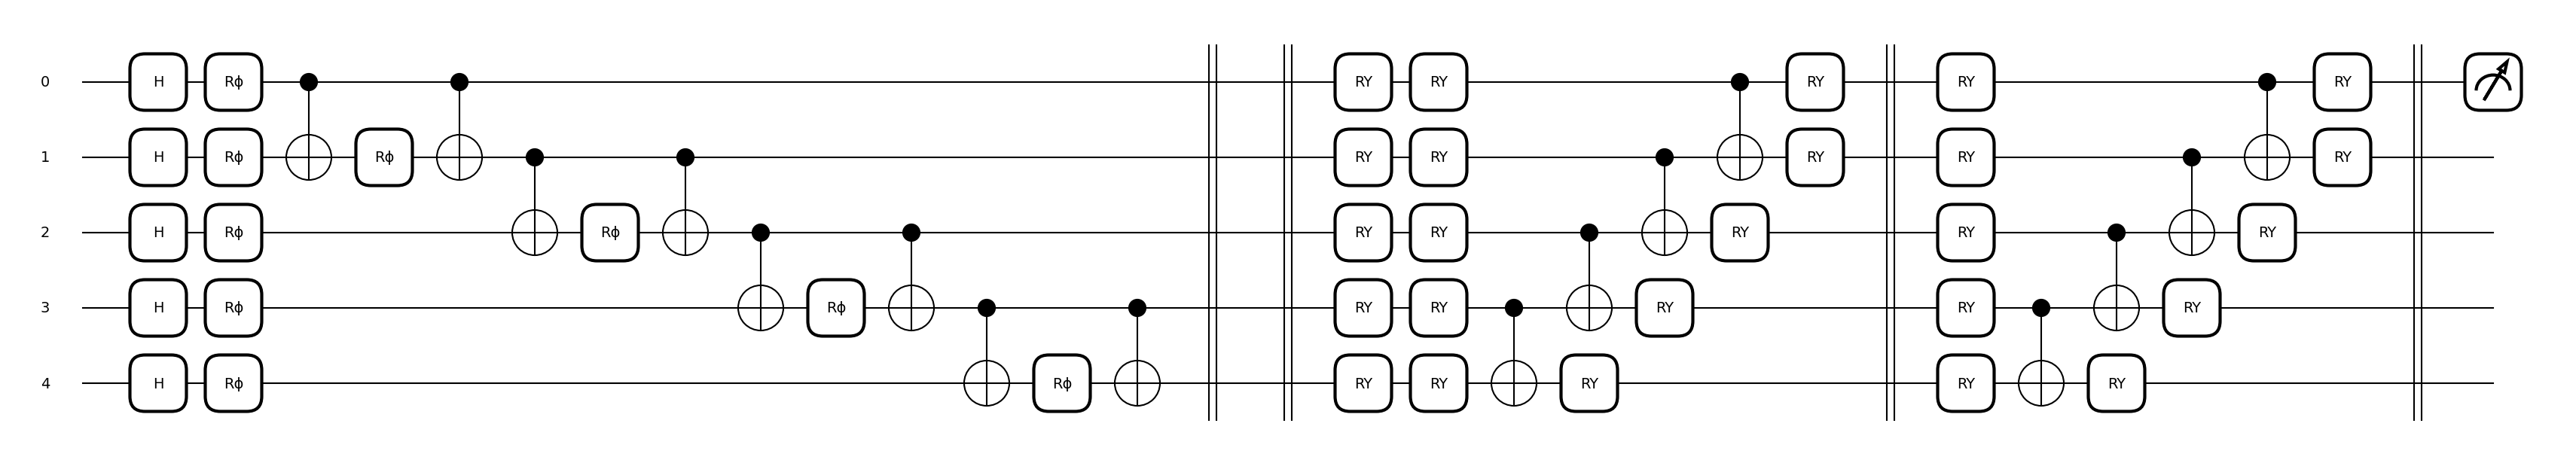

In [56]:
# / ----------------------- \ #
# | FM+Ansatz visualisation | #
# \ ----------------------- / #
qml.drawer.use_style('black_white')  # Optional style

#fig, ax = qml.draw_mpl(qml.transforms.decompose(many_shots_default_qvc_circuit), expansion_strategy="device")(np.append(X_train_sampled[0], [0.0]), init_params)
fig, ax = qml.draw_mpl(qml.transforms.decompose(many_shots_default_qvc_circuit), expansion_strategy="device")(X_train_sampled[0], init_params)
plt.show()

In [57]:
# Try forward pass
many_shots_default_qvc_forward(X_train_sampled[1], init_params)

(tensor([[ 1.],
         [-1.],
         [-1.],
         ...,
         [ 1.],
         [ 1.],
         [-1.]], requires_grad=True),
 tensor([[ 1.],
         [-1.],
         [-1.],
         ...,
         [ 1.],
         [ 1.],
         [-1.]], requires_grad=True),
 {'n_executions': 1024, 'n_valids': 1024, 'n_invalids': 0})

In [39]:
# Try loss function
many_shots_default_loss_fn(init_params, X_train_sampled[1], y_train_sampled[1])

(tensor(0.62168012, requires_grad=True),
 {'n_executions': 1024, 'n_valids': 1024, 'n_invalids': 0})

In [59]:
# Train QNN - One shot, Hamming distance, Unambiqous model
params = init_params.copy()
#params = trained_weights
# n_qubits = 3
epochs = 200
batch_size = 8

opt = qml.optimize.SPSAOptimizer(maxiter=epochs, a=None,)
# opt = qml.AdagradOptimizer(stepsize=0.05,)                         # 9 sec per epoch, 2 layers, data A, 3 qubits
# opt = qml.AdagradOptimizer(stepsize=0.05,)                       # 72 sec per epoch, 2 layers, data B, 5 qubits
# opt = qml.AdagradOptimizer(stepsize=0.01,)                       # 25 sec per epoch, 2 layers, data B, 3 qubits
# opt = qml.AdamOptimizer(stepsize=0.05,)                          # 47 sec per epoch, 2 layers, data C, 5 qubits
# opt = qml.AdamOptimizer(stepsize=0.1,)                           # 47 sec per epoch, 2 layers, data C, 3 qubits
# opt = qml.GradientDescentOptimizer(stepsize=0.5)
## opt = qml.NesterovMomentumOptimizer(stepsize=0.5)
# opt = RCDOptimizer(h=0.1)
#opt = qml.RMSPropOptimizer(stepsize=0.1, decay=0.7, eps=1e-08)  # 50 sec per epoch, 2 layers, data C, 5 qubits


trained_weights, history_per_batch, history_per_epoch = many_shots_default_train_qnn(X_train_sampled, y_train_sampled, opt=opt, loss_fn=many_shots_default_loss_fn, params=params, epochs=epochs, batch_size=batch_size)

Epoch 1
	Avg train Loss            : 0.6710
	Min/Avg/Max train # of executions : 1024/1024.0000/1024
	Train Accuracy	: 0.6044
	Train Precision	: 0.6395
	Train Recall	: 0.8497
	Train F1	: 0.7297
	Train ROC AUC	: 0.6489
	Train Min number of executions	: 1024.0000
	Train Avg number of executions	: 1024.0000
	Train Max number of executions	: 1024.0000
	Train Min number of valids	: 1024.0000
	Train Avg number of valids	: 1024.0000
	Train Max number of valids	: 1024.0000
	Train Min number of invalids	: 0.0000
	Train Avg number of invalids	: 0.0000
	Train Max number of invalids	: 0.0000
	Train Classification time[s]	: 19.1793
	Train Min time per forward pass[s]	: 0.0047
	Train Avg time per forward pass[s]	: 0.0084
	Train Max time per forward pass[s]	: 0.0622
Epoch 2
	Avg train Loss            : 0.6675
	Min/Avg/Max train # of executions : 1024/1024.0000/1024
	Train Accuracy	: 0.6000
	Train Precision	: 0.6347
	Train Recall	: 0.8566
	Train F1	: 0.7292
	Train ROC AUC	: 0.6722
	Train Min number of

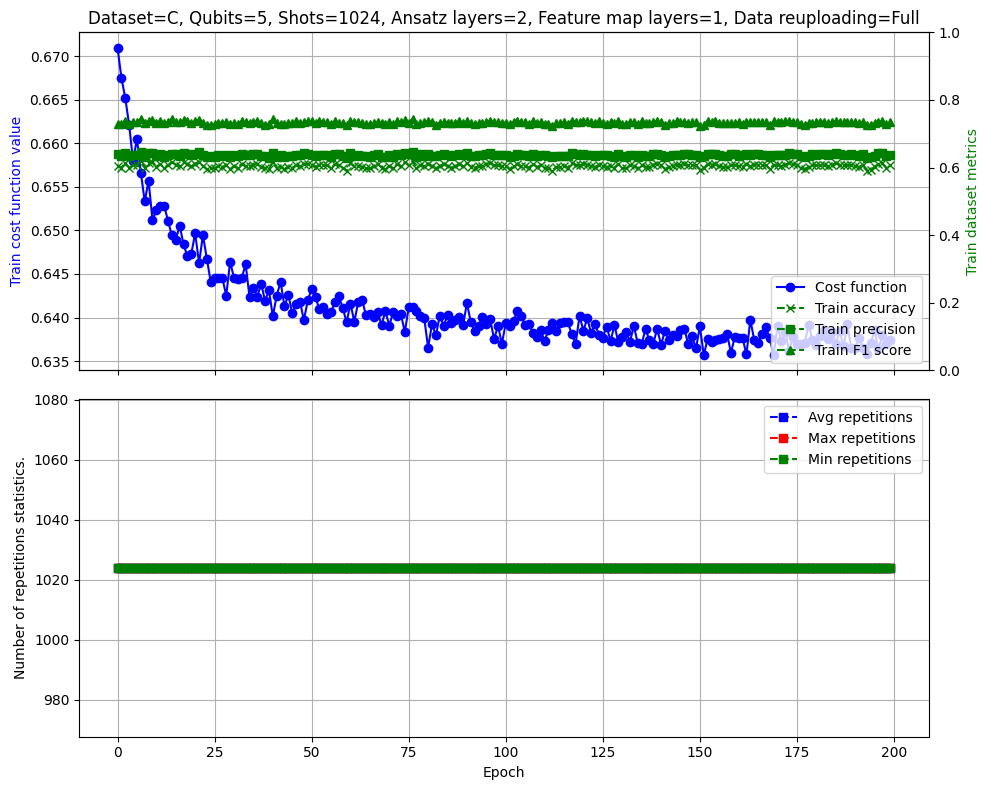

In [60]:
plot_history(history_per_epoch, output_file=training_history_plot_file, ansatz_layers=n_reps_ansatz, fm_layers=n_reps_fm, n_shots=n_shots, n_qubits=n_qubits, dataset=dataset, data_reuploading=data_reupload)

In [32]:
# Run the model on test data
get_metrics(X_test_sampled, y_test_sampled, trained_weights, forward_func=many_shots_default_qvc_forward, show = True)

Accuracy                         : 0.8158
Precision                        : 0.7907
Recall                           : 0.9577
F1 Score                         : 0.8662
ROC AUC                          : 0.9415
Min/Avg/Max # of executions      : 1024/1024.0000/1024
Classification time elapsed      : 0.1361207009977079s 
Min/Avg/Max forward time elapsed : 0/0/0


{'Accuracy': 0.8157894736842105,
 'Precision': 0.7906976744186046,
 'Recall': 0.9577464788732394,
 'F1': 0.8662420382165605,
 'ROC AUC': np.float64(0.9415329184408779),
 'Min number of executions': np.int64(1024),
 'Avg number of executions': np.float64(1024.0),
 'Max number of executions': np.int64(1024),
 'Classification time[s]': 0.1361207009977079,
 'Min time per forward pass[s]': 0,
 'Avg time per forward pass[s]': 0,
 'Max time per forward pass[s]': 0}

## QVC - many shots, Humming distance

In [44]:
# / -------------------------- \ #
# | QNN definition, Pennylane  | #
# \ -------------------------- / #

# Initialize hyperparameters specific to this model
n_shots = 1024
max_executions = n_shots

# Set up the quantum device
dev = qml.device("lightning.qubit", wires=n_qubits, shots=n_shots)
            
# Combine into a full PQC
@qml.qnode(dev)
def many_shots_hamming_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    #return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return [qml.sample(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit

In [45]:
# Try to run simulation on one data point
res = np.array(many_shots_hamming_qvc_circuit(X_train_sampled[0], init_params)).T

print(f"Dimension of output: {res.shape}\n")
print(f"Output:\n{res}")

Dimension of output: (1024, 5)

Output:
[[-1. -1.  1. -1.  1.]
 [ 1. -1. -1. -1.  1.]
 [ 1. -1.  1.  1.  1.]
 ...
 [-1.  1.  1.  1.  1.]
 [ 1. -1.  1.  1.  1.]
 [ 1. -1.  1.  1.  1.]]


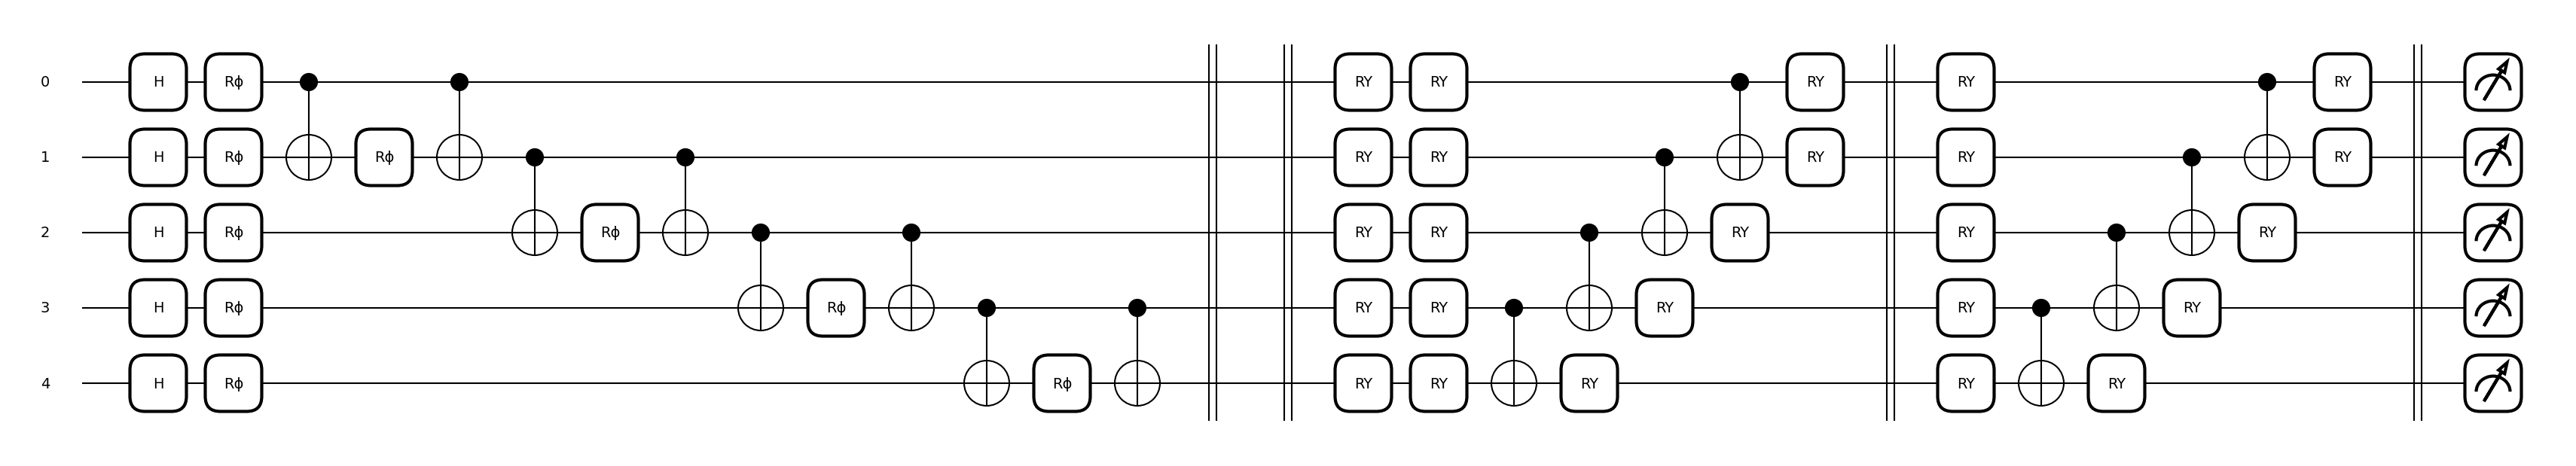

In [46]:
# / ----------------------- \ #
# | FM+Ansatz visualisation | #
# \ ----------------------- / #
qml.drawer.use_style('black_white')  # Optional style

#fig, ax = qml.draw_mpl(qml.transforms.decompose(many_shots_hamming_qvc_circuit), expansion_strategy="device")(np.append(X_train_sampled[0], [0.0]), init_params)
fig, ax = qml.draw_mpl(qml.transforms.decompose(many_shots_hamming_qvc_circuit), expansion_strategy="device")(X_train_sampled[0], init_params)
plt.show()

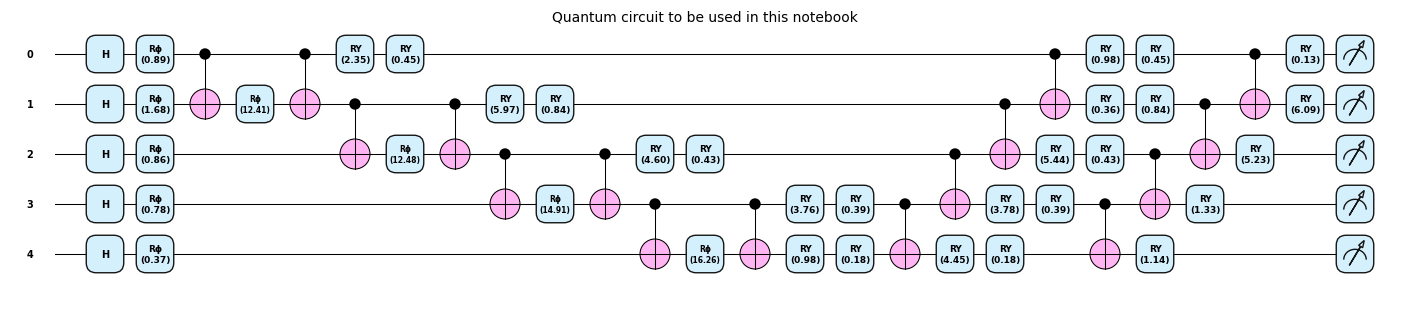

In [47]:
# / ----------------------- \ #
# | FM+Ansatz visualisation | #
# \ ----------------------- / #
draw_circuit(many_shots_hamming_qvc_circuit, scale=0.5, title='Quantum circuit to be used in this notebook', level='device')(X_train_sampled[0], init_params) # level='device'/'gradient'

In [48]:
# Try forward pass
many_shots_hamming_qvc_forward(X_train_sampled[0], init_params)

(tensor([[-1., -1.,  1., -1., -1.],
         [-1., -1., -1., -1.,  1.],
         [-1., -1.,  1.,  1.,  1.],
         ...,
         [ 1., -1.,  1.,  1., -1.],
         [-1., -1.,  1.,  1.,  1.],
         [ 1., -1.,  1.,  1.,  1.]], requires_grad=True),
 tensor([-1., -1.,  1., ...,  1.,  1.,  1.], requires_grad=True),
 {'n_executions': 1024, 'n_valids': 1024, 'n_invalids': 0})

In [30]:
# Try loss function
many_shots_hamming_loss_fn(init_params, X_train_sampled[0], y_train_sampled[0])

(tensor(0.34387277, requires_grad=True),
 {'n_executions': 1024, 'n_valids': 1024, 'n_invalids': 0})

In [49]:
# Train QNN - One shot, Hamming distance, Unambiqous model
params = init_params.copy()
#params = trained_weights
# n_qubits = 3
epochs = 200
batch_size = 8

opt = qml.optimize.SPSAOptimizer(maxiter=epochs, a=None,)
# opt = qml.AdagradOptimizer(stepsize=0.05,)                         # 9 sec per epoch, 2 layers, data A, 3 qubits
# opt = qml.AdagradOptimizer(stepsize=0.05,)                       # 72 sec per epoch, 2 layers, data B, 5 qubits
# opt = qml.AdagradOptimizer(stepsize=0.01,)                       # 25 sec per epoch, 2 layers, data B, 3 qubits
# opt = qml.AdamOptimizer(stepsize=0.05,)                          # 47 sec per epoch, 2 layers, data C, 5 qubits
# opt = qml.AdamOptimizer(stepsize=0.1,)                           # 47 sec per epoch, 2 layers, data C, 3 qubits
# opt = qml.GradientDescentOptimizer(stepsize=0.5)
## opt = qml.NesterovMomentumOptimizer(stepsize=0.5)
# opt = RCDOptimizer(h=0.1)
#opt = qml.RMSPropOptimizer(stepsize=0.1, decay=0.7, eps=1e-08)  # 50 sec per epoch, 2 layers, data C, 5 qubits


trained_weights, history_per_batch, history_per_epoch = many_shots_hamming_train_qnn(X_train_sampled, y_train_sampled, opt=opt, loss_fn=many_shots_hamming_loss_fn, params=params, epochs=epochs, batch_size=batch_size)

Epoch 1
	Avg train Loss            : 0.7079
	Min/Avg/Max train # of executions : 1024/1024.0000/1024
	Train Accuracy	: 0.5033
	Train Precision	: 0.6667
	Train Recall	: 0.4196
	Train F1	: 0.5150
	Train ROC AUC	: 0.5546
	Train Min number of executions	: 1024.0000
	Train Avg number of executions	: 1024.0000
	Train Max number of executions	: 1024.0000
	Train Min number of valids	: 1024.0000
	Train Avg number of valids	: 1024.0000
	Train Max number of valids	: 1024.0000
	Train Min number of invalids	: 0.0000
	Train Avg number of invalids	: 0.0000
	Train Max number of invalids	: 0.0000
	Train Classification time[s]	: 18.8348
	Train Min time per forward pass[s]	: 0.0055
	Train Avg time per forward pass[s]	: 0.0067
	Train Max time per forward pass[s]	: 0.0959
Epoch 2
	Avg train Loss            : 0.6919
	Min/Avg/Max train # of executions : 1024/1024.0000/1024
	Train Accuracy	: 0.5451
	Train Precision	: 0.6725
	Train Recall	: 0.5385
	Train F1	: 0.5981
	Train ROC AUC	: 0.5685
	Train Min number of

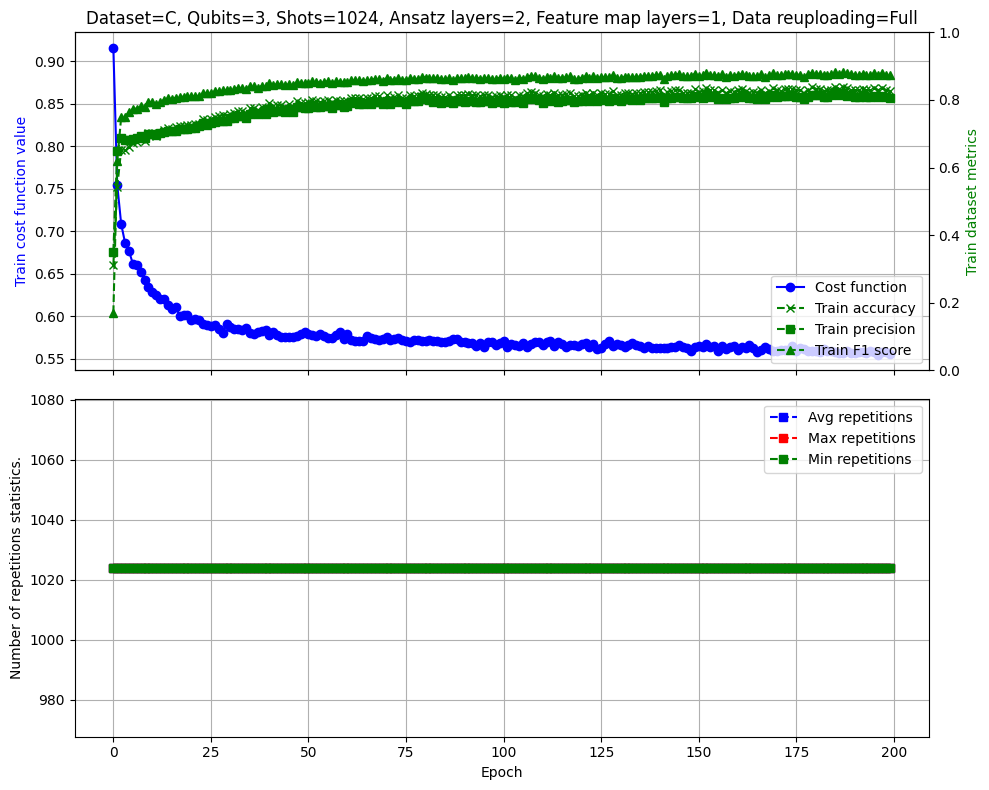

In [48]:
plot_history(history_per_epoch, output_file=training_history_plot_file, ansatz_layers=n_reps_ansatz, fm_layers=n_reps_fm, n_shots=n_shots, n_qubits=n_qubits, dataset=dataset, data_reuploading=data_reupload)

In [209]:
# Run the model on test data
get_metrics(X_test_sampled, y_test_sampled, trained_weights, forward_func=many_shots_hamming_qvc_forward, show = True)

Accuracy                         : 0.8246
Precision                        : 0.7865
Recall                           : 0.9859
F1 Score                         : 0.8750
ROC AUC                          : 0.9840
Min/Avg/Max # of executions      : 1024/1024.0000/1024
Classification time elapsed      : 0.2342931729999691s 
Min/Avg/Max forward time elapsed : 0/0/0


{'Accuracy': 0.8245614035087719,
 'Precision': 0.7865168539325843,
 'Recall': 0.9859154929577465,
 'F1': 0.875,
 'ROC AUC': 0.983950212905339,
 'Min number of executions': 1024,
 'Avg number of executions': 1024,
 'Max number of executions': 1024,
 'Classification time[s]': 0.2342931729999691,
 'Min time per forward pass[s]': 0,
 'Avg time per forward pass[s]': 0,
 'Max time per forward pass[s]': 0}

In [352]:
# Run the model on test data
get_metrics(X_test_sampled, y_test_sampled, trained_weights, forward_func=many_shots_hamming_qvc_forward, show = True)

Accuracy                         : 0.6842
Precision                        : 0.6667
Recall                           : 0.9859
F1 Score                         : 0.7955
ROC AUC                          : 0.6330
Min/Avg/Max # of executions      : 1024/1024.0000/1024
Min/Avg/Max # of valids          : 1024/1024.0000/1024
Min/Avg/Max # of invalids        : 0/0.0000/0
Classification time elapsed      : 4.477798283001903s 
Min/Avg/Max forward time elapsed : 0.003869484000460943/0.004631021657826894/0.009063661000254797


{'Accuracy': 0.6842105263157895,
 'Precision': 0.6666666666666666,
 'Recall': 0.9859154929577465,
 'F1': 0.7954545454545454,
 'ROC AUC': np.float64(0.6329839502129053),
 'Min number of executions': np.int64(1024),
 'Avg number of executions': np.float64(1024.0),
 'Max number of executions': np.int64(1024),
 'Min number of valids': np.int64(1024),
 'Avg number of valids': np.int64(1024),
 'Max number of valids': np.float64(1024.0),
 'Min number of invalids': np.int64(0),
 'Avg number of invalids': np.int64(0),
 'Max number of invalids': np.float64(0.0),
 'Classification time[s]': 4.477798283001903,
 'Min time per forward pass[s]': np.float64(0.003869484000460943),
 'Avg time per forward pass[s]': np.float64(0.004631021657826894),
 'Max time per forward pass[s]': np.float64(0.009063661000254797)}

## QVC - one shot, Humming distance + Unambiqous

In [81]:
# / -------------------------- \ #
# | QNN definition, Pennylane  | #
# \ -------------------------- / #

# Initialize hyperparameters specific to this model
n_shots = 128
max_executions = n_shots
#classify_threshold = n_qubits # defined as count of qubits, which needs to be measured and have same value to the number of all qubits.
classify_threshold = n_qubits # defined as absolute threshold for sum of exp values in range [0, n_qubits] 
#classify_threshold = 4 # defined as absolute threshold for sum of exp values in range [0, n_qubits] 

# Set up the quantum device
dev = qml.device("lightning.qubit", wires=n_qubits, shots=n_shots)
      
# Combine into a full PQC
@qml.qnode(dev)
def one_shot_hamming_unambiqous_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.sample(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit

In [41]:
# Try to run simulation on one data point
res = np.array(one_shot_hamming_unambiqous_qvc_circuit(X_train_sampled[0], init_params)).T

print(f"Dimension of output: {res.shape}\n")
print(f"Output:\n{res}")

Dimension of output: (128, 3)

Output:
[[ 1. -1. -1.]
 [ 1. -1. -1.]
 [-1.  1. -1.]
 [-1.  1. -1.]
 [-1. -1.  1.]
 [-1.  1. -1.]
 [ 1.  1.  1.]
 [-1.  1. -1.]
 [ 1.  1.  1.]
 [-1.  1. -1.]
 [ 1.  1.  1.]
 [ 1. -1. -1.]
 [ 1. -1. -1.]
 [ 1.  1.  1.]
 [-1.  1. -1.]
 [ 1.  1.  1.]
 [ 1. -1.  1.]
 [-1.  1. -1.]
 [-1.  1. -1.]
 [ 1. -1. -1.]
 [-1.  1.  1.]
 [-1.  1. -1.]
 [ 1. -1. -1.]
 [ 1.  1.  1.]
 [-1.  1.  1.]
 [ 1.  1.  1.]
 [ 1. -1.  1.]
 [ 1.  1.  1.]
 [ 1.  1.  1.]
 [ 1. -1. -1.]
 [-1.  1. -1.]
 [ 1. -1.  1.]
 [ 1.  1.  1.]
 [ 1.  1.  1.]
 [ 1.  1.  1.]
 [ 1.  1.  1.]
 [ 1. -1. -1.]
 [ 1. -1.  1.]
 [ 1.  1.  1.]
 [ 1.  1.  1.]
 [-1.  1. -1.]
 [ 1.  1.  1.]
 [ 1. -1. -1.]
 [ 1. -1. -1.]
 [ 1.  1.  1.]
 [-1.  1. -1.]
 [ 1. -1. -1.]
 [ 1. -1. -1.]
 [ 1. -1.  1.]
 [-1.  1. -1.]
 [ 1. -1. -1.]
 [-1.  1. -1.]
 [-1.  1. -1.]
 [ 1. -1.  1.]
 [ 1. -1.  1.]
 [-1.  1. -1.]
 [ 1.  1.  1.]
 [-1.  1. -1.]
 [ 1.  1.  1.]
 [ 1.  1.  1.]
 [ 1.  1.  1.]
 [ 1.  1.  1.]
 [ 1.  1.  1.]
 [ 1.  1. -1.]
 

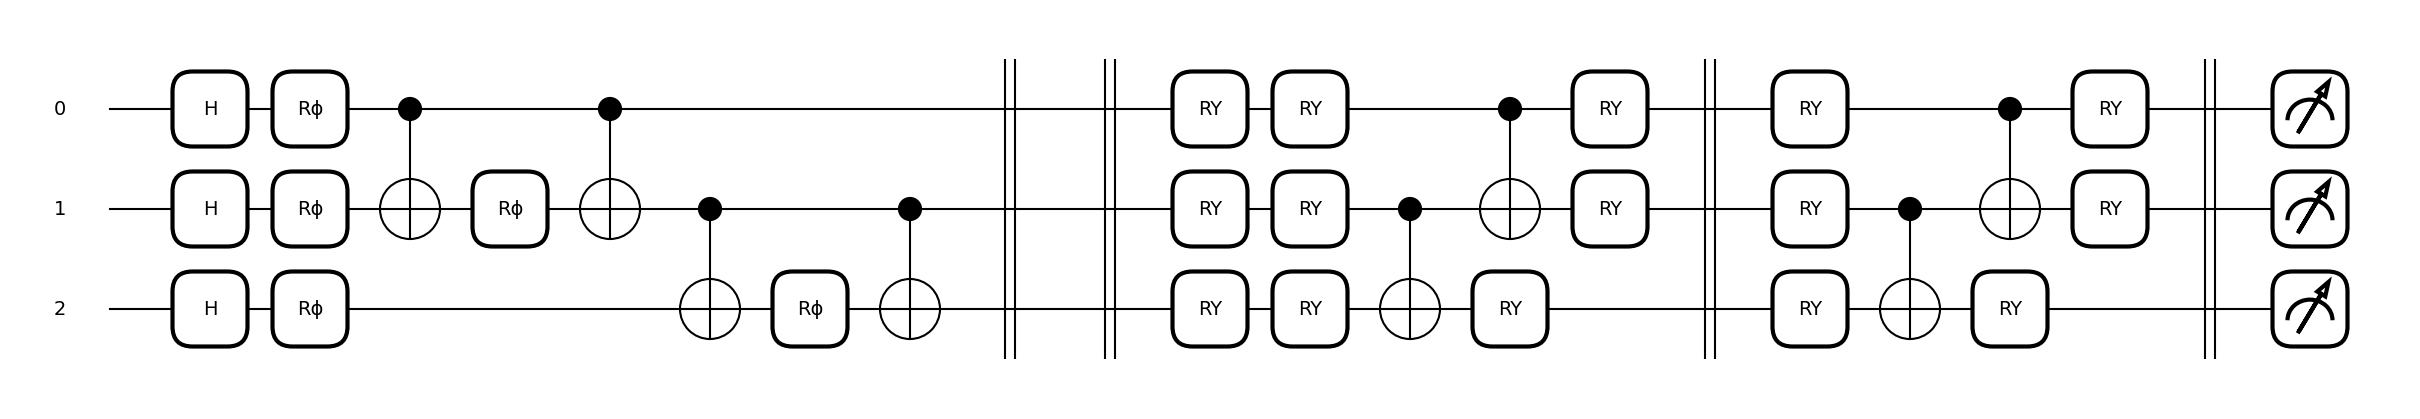

In [42]:
# / ----------------------- \ #
# | FM+Ansatz visualisation | #
# \ ----------------------- / #
qml.drawer.use_style('black_white')  # Optional style

#fig, ax = qml.draw_mpl(qml.transforms.decompose(one_shot_hamming_unambiqous_qvc_circuit), expansion_strategy="device")(np.append(X_train_sampled[0], [0.0]), init_params)
fig, ax = qml.draw_mpl(qml.transforms.decompose(one_shot_hamming_unambiqous_qvc_circuit), expansion_strategy="device")(X_train_sampled[0], init_params)
plt.show()

In [43]:
# Try forward pass
one_shot_hamming_unambiqous_qvc_forward(X_train_sampled[0], init_params)

(tensor([[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1

In [44]:
# Try loss function    
one_shot_hamming_unambiqous_loss_fn(init_params, X_train_sampled[0], y_train_sampled[0])

(tensor(0.04858735, requires_grad=True),
 {'n_executions': 128, 'n_valids': 51, 'n_invalids': 77})

In [82]:
# Train QNN - One shot, Hamming distance, Unambiqous model
params = init_params.copy()
#params = trained_weights
# n_qubits = 3
epochs = 200
batch_size = 8

opt = qml.optimize.SPSAOptimizer(maxiter=epochs, a=None,)
# opt = qml.AdagradOptimizer(stepsize=0.05,)                         # 9 sec per epoch, 2 layers, data A, 3 qubits
# opt = qml.AdagradOptimizer(stepsize=0.05,)                       # 72 sec per epoch, 2 layers, data B, 5 qubits
# opt = qml.AdagradOptimizer(stepsize=0.01,)                       # 25 sec per epoch, 2 layers, data B, 3 qubits
# opt = qml.AdamOptimizer(stepsize=0.05,)                          # 47 sec per epoch, 2 layers, data C, 5 qubits
# opt = qml.AdamOptimizer(stepsize=0.1,)                           # 47 sec per epoch, 2 layers, data C, 3 qubits
# opt = qml.GradientDescentOptimizer(stepsize=0.5)
## opt = qml.NesterovMomentumOptimizer(stepsize=0.5)
# opt = RCDOptimizer(h=0.1)
#opt = qml.RMSPropOptimizer(stepsize=0.1, decay=0.7, eps=1e-08)  # 50 sec per epoch, 2 layers, data C, 5 qubits

trained_weights, history_per_batch, history_per_epoch = one_shot_hamming_unambiqous_train_qnn(X_train_sampled, y_train_sampled, opt=opt, loss_fn=one_shot_hamming_unambiqous_loss_fn, params=params, epochs=epochs, batch_size=batch_size)

Epoch 1
	Avg train Loss            : 0.5241
	Min/Avg/Max train # of executions : 128/128.0000/128
	Train Accuracy	: 0.7868
	Train Precision	: 0.7872
	Train Recall	: 0.9056
	Train F1	: 0.8423
	Train ROC AUC	: 0.8597
	Train Min number of executions	: 128.0000
	Train Avg number of executions	: 128.0000
	Train Max number of executions	: 128.0000
	Train Min number of valids	: 3.0000
	Train Avg number of valids	: 27.3802
	Train Max number of valids	: 71.0000
	Train Min number of invalids	: 57.0000
	Train Avg number of invalids	: 100.6198
	Train Max number of invalids	: 125.0000
	Train Classification time[s]	: 6.6690
	Train Min time per forward pass[s]	: 0.0095
	Train Avg time per forward pass[s]	: 0.0134
	Train Max time per forward pass[s]	: 0.0834
Epoch 2
	Avg train Loss            : 0.4876
	Min/Avg/Max train # of executions : 128/128.0000/128
	Train Accuracy	: 0.8044
	Train Precision	: 0.8208
	Train Recall	: 0.8811
	Train F1	: 0.8499
	Train ROC AUC	: 0.8657
	Train Min number of executions	

In [85]:
history_per_epoch.keys()

dict_keys(['train_exec', 'train_valids', 'train_invalids', 'train_loss', 'train_avg_scores'])

In [87]:
len(history_per_epoch["train_valids"]["min"])

200

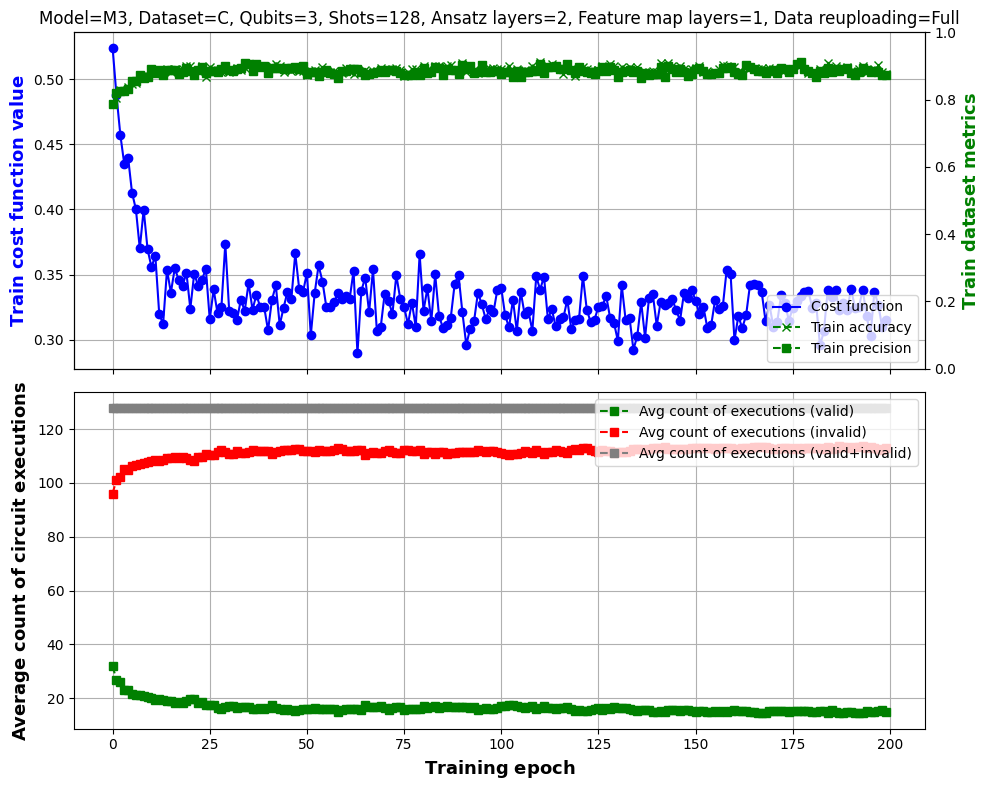

In [84]:
plot_history(history_per_epoch, output_file={training_history_plot_file}, ansatz_layers=n_reps_ansatz, fm_layers=n_reps_fm, n_shots=n_shots, n_qubits=n_qubits, dataset=dataset, data_reuploading=data_reupload, model="M3")

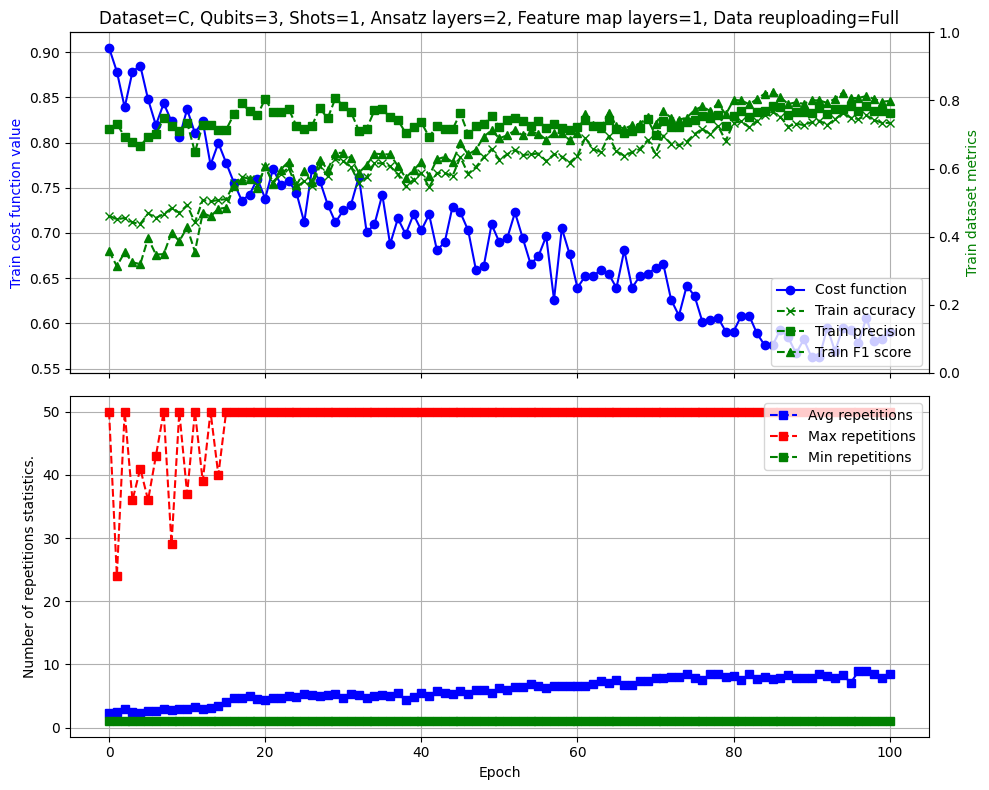

In [31]:
plot_history(history_per_epoch, output_file={training_history_plot_file}, ansatz_layers=n_reps_ansatz, fm_layers=n_reps_fm, n_shots=n_shots, n_qubits=n_qubits, dataset=dataset, data_reuploading=data_reupload)

In [109]:
# Run the model on test data
get_metrics(X_test_sampled, y_test_sampled, trained_weights, one_shot_hamming_unambiqous_qvc_forward, show = True)

Accuracy                    : 0.7895
Precision                   : 0.8310
Recall                      : 0.8310
F1 Score                    : 0.8310
ROC AUC                     : 0.7760
Min/Avg/Max # of executions : 1/2.6140/32


{'Accuracy': 0.7894736842105263,
 'Precision': 0.8309859154929577,
 'Recall': 0.8309859154929577,
 'F1': 0.8309859154929577,
 'ROC AUC': np.float64(0.7759580740255486)}

In [351]:
# Run the model on test data
get_metrics(X_test_sampled, y_test_sampled, trained_weights, one_shot_hamming_unambiqous_qvc_forward, show = True)

Accuracy                         : 0.6404
Precision                        : 0.7679
Recall                           : 0.6056
F1 Score                         : 0.6772
ROC AUC                          : 0.7535
Min/Avg/Max # of executions      : 1024/1024.0000/1024
Min/Avg/Max # of valids          : 1/1024.0000/47
Min/Avg/Max # of invalids        : 0/127.0000/88
Classification time elapsed      : 1.4567910639998445s 
Min/Avg/Max forward time elapsed : 0.009642560999054695/0.010952672886273112/0.030510876000334974


{'Accuracy': 0.6403508771929824,
 'Precision': 0.7678571428571429,
 'Recall': 0.6056338028169014,
 'F1': 0.6771653543307087,
 'ROC AUC': np.float64(0.7535211267605634),
 'Min number of executions': np.int64(1024),
 'Avg number of executions': np.float64(1024.0),
 'Max number of executions': np.int64(1024),
 'Min number of valids': np.int64(1),
 'Avg number of valids': np.int64(1024),
 'Max number of valids': np.float64(47.69298245614035),
 'Min number of invalids': np.int64(0),
 'Avg number of invalids': np.int64(127),
 'Max number of invalids': np.float64(88.16666666666667),
 'Classification time[s]': 1.4567910639998445,
 'Min time per forward pass[s]': np.float64(0.009642560999054695),
 'Avg time per forward pass[s]': np.float64(0.010952672886273112),
 'Max time per forward pass[s]': np.float64(0.030510876000334974)}

## Test

In [74]:
debug = True
num_of_iters = len(X_test_sampled)
num_of_iters = 5

forward_funcs = [many_shots_default_qvc_forward, many_shots_hamming_qvc_forward, one_shot_hamming_unambiqous_qvc_forward]
loss_funcs = [many_shots_default_loss_fn, many_shots_hamming_loss_fn, one_shot_hamming_unambiqous_loss_fn]


for i in range(len(forward_funcs)):
    forward_func = forward_funcs[i]
    loss_func = loss_funcs[i]
    print(f"Model: M{i+1}")
    
    weights_file = f"w_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={i+1}.v{version}.npy"
    weights = np.array(np.load(f"./weights/{weights_file}", allow_pickle=True), requires_grad=True)
    y_true_list = []
    y_pred_list = []
    
    for j in range(num_of_iters):
        y_scores, y_preds, stats1 = forward_func(X_test_sampled[j], weights)
        loss_value, stats2 = loss_func(weights, X_test_sampled[j], y_test_sampled[j])
        
        # Total votes
        total = len(y_preds)
        
        # Probability for each class
        class_1_cnt = sum(y_preds == 1)
        class_0_cnt = sum(y_preds == -1)
        
        prob_1 = class_1_cnt / total
        prob_0 = class_0_cnt / total
        # classify
        y_pred = 1 if prob_1 >= prob_0 else 0
    
        if debug:
            print(f"total shots = {total}")
            print(f"Loss value: {loss_value.item():.4f}")
            print(f"Counts: 0({class_0_cnt.item()}) x 1({class_1_cnt.item()})")
            print(f"Probs: 0({prob_0.item():.2f} %) x 1({prob_1.item():.2f} %)")
            print(f"y_pred = {y_pred}, y_true = {y_train_sampled[j]}")
            for k in range(0, min(10, total)):
                print(f"\t{y_scores[k]} -> {y_preds[k]}")
            print(f"\t...")
            print()
    
        y_true_list.append(y_test_sampled[j])
        y_pred_list.append(y_pred)
    
    accuracy = accuracy_score(y_true_list, y_pred_list)
    print(f"Accuracy: {accuracy}")
    print(f"--------------------------------------")
    print(f"--------------------------------------")
    print(f"--------------------------------------\n")

Model: M1
total shots = 1024
Loss value: 0.4106
Counts: 0(163) x 1(861)
Probs: 0(0.16 %) x 1(0.84 %)
y_pred = 1, y_true = 1
	[1.] -> [1.]
	[-1.] -> [-1.]
	[1.] -> [1.]
	[-1.] -> [-1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	...

total shots = 1024
Loss value: 1.0461
Counts: 0(210) x 1(814)
Probs: 0(0.21 %) x 1(0.79 %)
y_pred = 1, y_true = 0
	[-1.] -> [-1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[-1.] -> [-1.]
	[1.] -> [1.]
	[-1.] -> [-1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	...

total shots = 1024
Loss value: 0.9716
Counts: 0(237) x 1(787)
Probs: 0(0.23 %) x 1(0.77 %)
y_pred = 1, y_true = 1
	[1.] -> [1.]
	[-1.] -> [-1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[-1.] -> [-1.]
	[1.] -> [1.]
	...

total shots = 1024
Loss value: 0.4756
Counts: 0(231) x 1(793)
Probs: 0(0.23 %) x 1(0.77 %)
y_pred = 1, y_true = 1
	[1.] -> [1.]
	[1.] -> [1.]
	[1.] -> [1.]
	[-1.] -> [-1.]
	[1.] -> [1.]
	[1.] -> [

# Comparison

In [14]:
# save/load training history
mode = "load" # "save", "overwrite", "load"

if mode == "save":
    if os.path.exists(f"./results/{training_history_file}"):
        print(f"⚠️ Warning: ./results/{training_history_file} already exists!")
    else:
        with open(f"./results/{training_history_file}", "w") as f:
            history_per_epoch["train_loss"]["avg"] = [float(x) for x in history_per_epoch["train_loss"]["avg"]]
            history_per_epoch["train_exec"]["min"] = [int(x) for x in history_per_epoch["train_exec"]["min"]]
            history_per_epoch["train_exec"]["max"] = [int(x) for x in history_per_epoch["train_exec"]["max"]]         
            history_per_epoch["train_exec"]["avg"] = [float(x) for x in history_per_epoch["train_exec"]["avg"]]    
            history_per_epoch["train_valids"]["min"] = [int(x) for x in history_per_epoch["train_valids"]["min"]]
            history_per_epoch["train_valids"]["max"] = [int(x) for x in history_per_epoch["train_valids"]["max"]]         
            history_per_epoch["train_valids"]["avg"] = [float(x) for x in history_per_epoch["train_valids"]["avg"]]  
            history_per_epoch["train_invalids"]["min"] = [int(x) for x in history_per_epoch["train_invalids"]["min"]]
            history_per_epoch["train_invalids"]["max"] = [int(x) for x in history_per_epoch["train_invalids"]["max"]]         
            history_per_epoch["train_invalids"]["avg"] = [float(x) for x in history_per_epoch["train_invalids"]["avg"]]  
            
            history_per_epoch["train_avg_scores"]["Accuracy"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Accuracy"]]
            history_per_epoch["train_avg_scores"]["Precision"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Precision"]]
            history_per_epoch["train_avg_scores"]["Recall"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Recall"]]
            history_per_epoch["train_avg_scores"]["F1"] = [float(x) for x in history_per_epoch["train_avg_scores"]["F1"]]
            history_per_epoch["train_avg_scores"]["ROC AUC"] = [float(x) for x in history_per_epoch["train_avg_scores"]["ROC AUC"]]
            history_per_epoch["train_avg_scores"]["Min number of executions"] = [int(x) for x in history_per_epoch["train_avg_scores"]["Min number of executions"]]
            history_per_epoch["train_avg_scores"]["Avg number of executions"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Avg number of executions"]]
            history_per_epoch["train_avg_scores"]["Max number of executions"] = [int(x) for x in history_per_epoch["train_avg_scores"]["Max number of executions"]]
            history_per_epoch["train_avg_scores"]["Min number of valids"] = [int(x) for x in history_per_epoch["train_avg_scores"]["Min number of valids"]]
            history_per_epoch["train_avg_scores"]["Avg number of valids"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Avg number of valids"]]
            history_per_epoch["train_avg_scores"]["Max number of valids"] = [int(x) for x in history_per_epoch["train_avg_scores"]["Max number of valids"]]
            history_per_epoch["train_avg_scores"]["Min number of invalids"] = [int(x) for x in history_per_epoch["train_avg_scores"]["Min number of invalids"]]
            history_per_epoch["train_avg_scores"]["Avg number of invalids"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Avg number of invalids"]]
            history_per_epoch["train_avg_scores"]["Max number of invalids"] = [int(x) for x in history_per_epoch["train_avg_scores"]["Max number of invalids"]]
            history_per_epoch["train_avg_scores"]["Classification time[s]"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Classification time[s]"]]
            history_per_epoch["train_avg_scores"]["Min time per forward pass[s]"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Min time per forward pass[s]"]]
            history_per_epoch["train_avg_scores"]["Avg time per forward pass[s]"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Avg time per forward pass[s]"]]
            history_per_epoch["train_avg_scores"]["Max time per forward pass[s]"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Max time per forward pass[s]"]]

            json.dump(history_per_epoch, f, indent=4)
elif mode == "overwrite":
    with open(f"./results/{training_history_file}", "w") as f:
        history_per_epoch["train_loss"]["avg"] = [float(x) for x in history_per_epoch["train_loss"]["avg"]]
        history_per_epoch["train_exec"]["min"] = [int(x) for x in history_per_epoch["train_exec"]["min"]]
        history_per_epoch["train_exec"]["max"] = [int(x) for x in history_per_epoch["train_exec"]["max"]]
        history_per_epoch["train_exec"]["avg"] = [float(x) for x in history_per_epoch["train_exec"]["avg"]]
        json.dump(history_per_epoch, f, indent=4)
elif mode == "load":
    with open(f"./results/{training_history_file}", "r") as f:
        loaded_history_per_epoch = json.load(f)
        print(loaded_history_per_epoch.keys())

dict_keys(['train_exec', 'train_valids', 'train_invalids', 'train_loss', 'train_avg_scores'])


In [10]:
loaded_history_per_epoch["train_valids"].keys()

dict_keys(['avg', 'min', 'max'])

In [39]:
max(loaded_history_per_epoch["train_avg_scores"]["Accuracy"])

0.7098901098901099

In [11]:
min(loaded_history_per_epoch["train_valids"]["min"])

7

In [15]:
min(loaded_history_per_epoch["train_valids"]["min"])

1

Path already exists


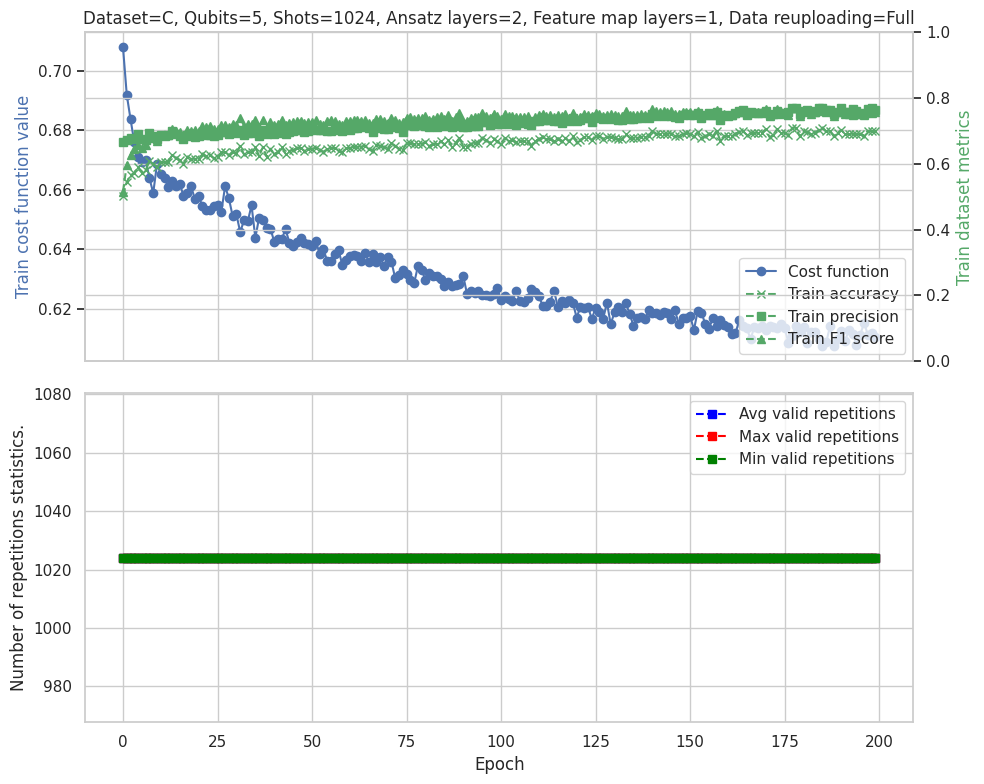

In [104]:
plot_history(loaded_history_per_epoch, output_file=training_history_plot_file, ansatz_layers=n_reps_ansatz, fm_layers=n_reps_fm, n_shots=n_shots, n_qubits=n_qubits, dataset=dataset, data_reuploading=data_reupload)

In [34]:
# save/load trained weights 
mode = "load" # "save", "overwrite", "load"
#weights_file = "w_qubits=3_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=C_trained=2.v2.npy"

if mode == "save":
    if os.path.exists(f"./weights/{weights_file}"):
        print(f"⚠️ Warning: ./weights/{weights_file} already exists!")
    else:
        np.save(f"./weights/{weights_file}", trained_weights)
elif mode == "overwrite":
    np.save(f"./weights/{weights_file}", trained_weights)
elif mode == "load":
    # Load trained weights
    loaded_weights = np.load(f"./weights/{weights_file}", allow_pickle=True)
    loaded_weights = np.array(loaded_weights, requires_grad=True)
    print(loaded_weights)

[[2.23067822 6.08711406 4.49587394 4.50352531 0.47851401]
 [0.82759518 0.38258099 5.28062065 3.84143862 5.48520115]
 [0.09708057 5.7915088  5.45563312 1.15773092 1.791304  ]]


In [35]:
# define number of classification runs for each experiment
n_classification_iterations = 25
add_noise_qnode = functools.partial(add_noise, p_depol=0.02, p_amp=0.05, p_phase=0.03) # define noise model

## Experiment 1

### Noiseless

In [122]:
# Experiment 1, many shots, one qubit decision
n_shots = 1024
max_executions = n_shots
#dev = qml.device("qiskit.aer", backend_name="aer_simulator", wires=n_qubits, shots=n_shots, noise_model=None)
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )
# Combine into a full PQC
@qml.qnode(dev)
def many_shots_default_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.sample(qml.PauliZ(0))]
    #return [qml.expval(qml.PauliZ(0))]
    #return qml.sample(wires=[0])  # samples in Z-basis on single qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, many_shots_default_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "X", "noise_model": "None"}
    data.update(metrics)
    temp.append(data)

df_exp1_noiseless = pd.DataFrame(temp)
del temp
df_exp1_noiseless.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,...,Min number of valids,Avg number of valids,Max number of valids,Min number of invalids,Avg number of invalids,Max number of invalids,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,X,None,0.657895,0.650943,0.971831,0.779661,0.783000,1024,...,1024,1024,1024.0,0,0,0.0,5.146417,0.020918,0.023263,0.044065
1,2,C,X,None,0.666667,0.660194,0.957746,0.781609,0.776449,1024,...,1024,1024,1024.0,0,0,0.0,5.467643,0.021143,0.024833,0.050869
2,3,C,X,None,0.657895,0.656863,0.943662,0.774566,0.783328,1024,...,1024,1024,1024.0,0,0,0.0,5.467735,0.021127,0.024157,0.036699
3,4,C,X,None,0.649123,0.647619,0.957746,0.772727,0.786603,1024,...,1024,1024,1024.0,0,0,0.0,5.280685,0.020973,0.023823,0.037064
4,5,C,X,None,0.649123,0.653465,0.929577,0.767442,0.780708,1024,...,1024,1024,1024.0,0,0,0.0,5.315875,0.021036,0.023784,0.035676


### Noise

In [123]:
# Experiment 1, many shots, one qubit decision
n_shots = 1024
max_executions = n_shots
#dev = qml.device("qiskit.aer", backend_name="aer_simulator", wires=n_qubits, shots=n_shots, noise_model=noise_model)
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )

# Combine into a full PQC
@qml.qnode(dev)
@add_noise_qnode
def many_shots_default_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.sample(qml.PauliZ(0))]
    #return [qml.expval(qml.PauliZ(0))]
    #return qml.sample(wires=[0])  # samples in Z-basis on single qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, many_shots_default_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "X", "noise_model": "Basic"}
    data.update(metrics)
    temp.append(data)

df_exp1_noise = pd.DataFrame(temp)
del temp
df_exp1_noise.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,...,Min number of valids,Avg number of valids,Max number of valids,Min number of invalids,Avg number of invalids,Max number of invalids,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,X,Basic,0.622807,0.622807,1.0,0.767568,0.796757,1024,...,1024,1024,1024.0,0,0,0.0,16.375667,0.097205,0.119448,0.283676
1,2,C,X,Basic,0.622807,0.622807,1.0,0.767568,0.810187,1024,...,1024,1024,1024.0,0,0,0.0,15.948526,0.098888,0.116004,0.265447
2,3,C,X,Basic,0.622807,0.622807,1.0,0.767568,0.807239,1024,...,1024,1024,1024.0,0,0,0.0,15.514087,0.099018,0.113205,0.234638
3,4,C,X,Basic,0.622807,0.622807,1.0,0.767568,0.822797,1024,...,1024,1024,1024.0,0,0,0.0,15.617469,0.098752,0.113762,0.301351
4,5,C,X,Basic,0.622807,0.622807,1.0,0.767568,0.807566,1024,...,1024,1024,1024.0,0,0,0.0,15.616029,0.097753,0.113444,0.231550


## Experiment 2

### Noiseless

In [36]:
# Experiment 2, many shots, hamming
n_shots = 1024
max_executions = n_shots
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )
# Combine into a full PQC
@qml.qnode(dev)
def many_shots_hamming_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.sample(qml.PauliZ(i)) for i in range(n_qubits)]
    #return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, many_shots_hamming_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "Y", "noise_model": "None"}
    data.update(metrics)
    temp.append(data)

df_exp2_noiseless = pd.DataFrame(temp)
del temp
df_exp2_noiseless.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,...,Min number of valids,Avg number of valids,Max number of valids,Min number of invalids,Avg number of invalids,Max number of invalids,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,Y,None,0.622807,0.679487,0.746479,0.711409,0.684900,1024,...,1024,1024.0,1024,0,0.0,0,7.121328,0.020996,0.024848,0.097891
1,2,C,Y,None,0.640351,0.687500,0.774648,0.728477,0.653128,1024,...,1024,1024.0,1024,0,0.0,0,7.318536,0.021144,0.024821,0.048520
2,3,C,Y,None,0.631579,0.674699,0.788732,0.727273,0.662954,1024,...,1024,1024.0,1024,0,0.0,0,7.145538,0.021167,0.024356,0.039999
3,4,C,Y,None,0.640351,0.692308,0.760563,0.724832,0.671307,1024,...,1024,1024.0,1024,0,0.0,0,7.109705,0.020887,0.024019,0.031590
4,5,C,Y,None,0.622807,0.675000,0.760563,0.715232,0.665247,1024,...,1024,1024.0,1024,0,0.0,0,7.112336,0.021252,0.024175,0.031847


### Noise

In [128]:
# Experiment 2, many shots, hamming
n_shots = 1024
max_executions = n_shots
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )
# Combine into a full PQC
@qml.qnode(dev)
@add_noise_qnode
def many_shots_hamming_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.sample(qml.PauliZ(i)) for i in range(n_qubits)]
    #return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, many_shots_hamming_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "Y", "noise_model": "Basic"}
    data.update(metrics)
    temp.append(data)

df_exp2_noise = pd.DataFrame(temp)
del temp
df_exp2_noise.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,...,Min number of valids,Avg number of valids,Max number of valids,Min number of invalids,Avg number of invalids,Max number of invalids,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,Y,Basic,0.622807,0.622807,1.0,0.767568,0.730757,1024,...,1024,1024,1024.0,0,0,0.0,18.593649,0.109721,0.122147,0.257494
1,2,C,Y,Basic,0.631579,0.628319,1.0,0.771739,0.707173,1024,...,1024,1024,1024.0,0,0,0.0,18.758843,0.109133,0.123457,0.246448
2,3,C,Y,Basic,0.622807,0.622807,1.0,0.767568,0.743040,1024,...,1024,1024,1024.0,0,0,0.0,18.050586,0.106522,0.118778,0.176179
3,4,C,Y,Basic,0.622807,0.622807,1.0,0.767568,0.707828,1024,...,1024,1024,1024.0,0,0,0.0,18.545084,0.104739,0.122234,0.242831
4,5,C,Y,Basic,0.622807,0.622807,1.0,0.767568,0.750246,1024,...,1024,1024,1024.0,0,0,0.0,18.165308,0.098559,0.119724,0.248323


## Experiment 3

### Noiseless

In [133]:
# Experiment 3 - one shot, hamming, unambiqous
n_shots = 128
max_executions = 50
classify_threshold = n_qubits # defined as count of qubits, which needs to be measured and have same value to the number of all qubits.
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )
# Combine into a full PQC
@qml.qnode(dev)
def one_shot_hamming_unambiqous_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.sample(qml.PauliZ(i)) for i in range(n_qubits)]
    #return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, one_shot_hamming_unambiqous_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "Z", "noise_model": "None"}
    data.update(metrics)
    temp.append(data)

df_exp3_noiseless = pd.DataFrame(temp)
del temp
df_exp3_noiseless.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,...,Min number of valids,Avg number of valids,Max number of valids,Min number of invalids,Avg number of invalids,Max number of invalids,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,Z,None,0.754386,0.736264,0.943662,0.827160,0.849165,128,...,1,128,12.622807,0,127,115.377193,3.966990,0.027086,0.034224,0.268278
1,2,C,Z,None,0.763158,0.739130,0.957746,0.834356,0.828693,128,...,1,128,14.122807,0,127,113.877193,3.552738,0.027242,0.030526,0.047798
2,3,C,Z,None,0.780702,0.761364,0.943662,0.842767,0.820341,128,...,1,128,11.061404,0,127,116.938596,3.598160,0.027202,0.031036,0.039294
3,4,C,Z,None,0.763158,0.739130,0.957746,0.834356,0.877006,128,...,1,128,11.570175,0,127,116.429825,3.721785,0.027341,0.032098,0.049594
4,5,C,Z,None,0.798246,0.785714,0.929577,0.851613,0.902882,128,...,1,128,8.964912,0,127,119.035088,3.807646,0.027315,0.032927,0.069522


### Noise

In [134]:
# Experiment 3 - one shot, hamming, unambiqous
n_shots = 128
max_executions = 50
classify_threshold = n_qubits         # defined as count of qubits, which needs to be measured and have same value to the number of all qubits.
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )
# Combine into a full PQC
@qml.qnode(dev)
@add_noise_qnode
def one_shot_hamming_unambiqous_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.sample(qml.PauliZ(i)) for i in range(n_qubits)]
    #return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, one_shot_hamming_unambiqous_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "Z", "noise_model": "Basic"}
    data.update(metrics)
    temp.append(data)

df_exp3_noise = pd.DataFrame(temp)
del temp
df_exp3_noise.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,...,Min number of valids,Avg number of valids,Max number of valids,Min number of invalids,Avg number of invalids,Max number of invalids,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,Z,Basic,0.631579,0.630631,0.985915,0.769231,0.561415,128,...,2,21,10.710526,107,126,117.289474,14.092381,0.104416,0.123047,0.206953
1,2,C,Z,Basic,0.631579,0.628319,1.000000,0.771739,0.630364,128,...,4,19,11.017544,109,124,116.982456,14.189315,0.110502,0.123903,0.264201
2,3,C,Z,Basic,0.614035,0.619469,0.985915,0.760870,0.533737,128,...,4,18,10.535088,110,124,117.464912,14.426228,0.103900,0.125981,0.243048
3,4,C,Z,Basic,0.622807,0.625000,0.985915,0.765027,0.578120,128,...,4,19,10.500000,109,124,117.500000,14.381784,0.112980,0.125600,0.246999
4,5,C,Z,Basic,0.640351,0.633929,1.000000,0.775956,0.580904,128,...,2,19,10.666667,109,126,117.333333,14.766095,0.116220,0.128950,0.357769


## Result analysis

In [135]:
# merge all results
kind = "all" # all, noise-only, noiseless-only
save_plot = True

if kind == "all":
    df_experiments = pd.concat([df_exp1_noiseless, df_exp1_noise,
                                df_exp2_noiseless, df_exp2_noise,
                                df_exp3_noiseless, df_exp3_noise], ignore_index=True)
elif kind == "noiseless-only":
    df_experiments = pd.concat([df_exp1_noiseless,
                                df_exp2_noiseless,
                                df_exp3_noiseless,], ignore_index=True)
elif kind == "noise-only": 
    df_experiments = pd.concat([df_exp1_noise,
                                df_exp2_noise,
                                df_exp3_noise], ignore_index=True)

In [92]:
# df_experiments = pd.read_csv("results/r_qubits=5_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=C_trained=2.v2.csv")

In [93]:
# df_experiments.shape, df_experiments.columns, df_experiments.model.unique()

((150, 16),
 Index(['iteration', 'dataset', 'model', 'noise_model', 'Accuracy', 'Precision',
        'Recall', 'F1', 'ROC AUC', 'Min number of executions',
        'Avg number of executions', 'Max number of executions',
        'Classification time[s]', 'Min time per forward pass[s]',
        'Avg time per forward pass[s]', 'Max time per forward pass[s]'],
       dtype='object'),
 array(['X', 'Y', 'Z'], dtype=object))

In [94]:
# df_experiments = df_experiments.loc[df_experiments.model != "X"]

In [95]:
# Load the saved part results
# df_exp1_noiseless = pd.read_csv(f"./results/r_qubits=5_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=C_trained=1.v2.csv_1_a")
# df_exp1_noise     = pd.read_csv(f"./results/r_qubits=5_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=C_trained=1.v2.csv_1_b")


In [96]:
# df_experiments = pd.concat([df_exp1_noiseless, df_exp1_noise, df_experiments], ignore_index=True)

In [97]:
# df_experiments["noise_model"] = df_experiments["noise_model"].fillna("None")
# df_experiments[["Precision","Recall", "F1"]] = df_experiments[["Precision","Recall", "F1"]].replace(0, None)

In [30]:
# save/load part results
# df_exp1_noiseless.to_csv(f"./results/{results_file}_1_a", index=False)  # index=False avoids saving the row numbers
# df_exp1_noise.to_csv(f"./results/{results_file}_1_b", index=False)  # index=False avoids saving the row numbers
# df_exp2_noiseless.to_csv(f"./results/{results_file}_2_a", index=False)  # index=False avoids saving the row numbers
# df_exp2_noise.to_csv(f"./results/{results_file}_2_b", index=False)  # index=False avoids saving the row numbers
# df_exp3_noiseless.to_csv(f"./results/{results_file}_3_a", index=False)  # index=False avoids saving the row numbers
# #df_exp3_noise.to_csv(f"./results/{results_file}_3_b", index=False)  # index=False avoids saving the row numbers

In [57]:
# Load the saved part results
# df_exp1_noiseless = pd.read_csv(f"./results/{results_file}_1_a")
# df_exp1_noise     = pd.read_csv(f"./results/{results_file}_1_b")
# df_exp2_noiseless = pd.read_csv(f"./results/{results_file}_2_a")
# df_exp2_noise     = pd.read_csv(f"./results/{results_file}_2_b")
# df_exp3_noiseless = pd.read_csv(f"./results/{results_file}_3_a")
# # df_exp3_noise     = pd.read_csv(f"./results/{results_file}_3_b")  # if you later save it

In [44]:
n_qubits = 3
n_reps_fm = 1
n_reps_ansatz = 2
data_reupload = "Full" # Full, Partial(default)
dataset = "C"

trained_on_model = 3
version = 3
weights_file = f"w_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v{version}.npy"
results_file = f"r_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v{version}.csv"
training_history_file = f"h_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v{version}.json"
training_history_plot_file = f"h_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v{version}.pdf"

In [45]:
# save/load all results
mode = "load" # "save", "overwrite", "load"
#results_file = "r_qubits=5_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=A_trained=2.v2.csv"

if mode == "save":
    if os.path.exists(f"./results/{results_file}"):
        print(f"⚠️ Warning: ./results/{results_file} already exists!")
    else:
        df_experiments.to_csv(f"./results/{results_file}", index=False)  # index=False avoids saving the row numbers
elif mode == "overwrite":
    df_experiments.to_csv(f"./results/{results_file}", index=False)  # index=False avoids saving the row numbers
elif mode == "load":
    loaded_df_experiments = pd.read_csv(f"./results/{results_file}")
    loaded_df_experiments["noise_model"] = loaded_df_experiments["noise_model"].fillna("None")
    loaded_df_experiments[["Precision","Recall", "F1"]] = loaded_df_experiments[["Precision","Recall", "F1"]].replace(0, None)
    

In [58]:
df_experiments = loaded_df_experiments

In [59]:
df_experiments.shape

(150, 22)

In [60]:
df_experiments.columns

Index(['iteration', 'dataset', 'model', 'noise_model', 'Accuracy', 'Precision',
       'Recall', 'F1', 'ROC AUC', 'Min number of executions',
       'Avg number of executions', 'Max number of executions',
       'Min number of valids', 'Max number of valids', 'Avg number of valids',
       'Min number of invalids', 'Max number of invalids',
       'Avg number of invalids', 'Classification time[s]',
       'Min time per forward pass[s]', 'Avg time per forward pass[s]',
       'Max time per forward pass[s]'],
      dtype='object')

In [61]:
df_experiments.head()

,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,...,Min number of valids,Max number of valids,Avg number of valids,Min number of invalids,Max number of invalids,Avg number of invalids,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,X,None,0.657895,0.650943,0.971831,0.779661,0.783000,1024,...,1024,1024,1024.0,0,0,0.0,5.146417,0.020918,0.023263,0.044065
1,2,C,X,None,0.666667,0.660194,0.957746,0.781609,0.776449,1024,...,1024,1024,1024.0,0,0,0.0,5.467643,0.021143,0.024833,0.050869
2,3,C,X,None,0.657895,0.656863,0.943662,0.774566,0.783328,1024,...,1024,1024,1024.0,0,0,0.0,5.467735,0.021127,0.024157,0.036699
3,4,C,X,None,0.649123,0.647619,0.957746,0.772727,0.786603,1024,...,1024,1024,1024.0,0,0,0.0,5.280685,0.020973,0.023823,0.037064
4,5,C,X,None,0.649123,0.653465,0.929577,0.767442,0.780708,1024,...,1024,1024,1024.0,0,0,0.0,5.315875,0.021036,0.023784,0.035676


In [62]:
df_experiments.loc[(df_experiments["noise_model"]=="None") & (df_experiments["model"] == "Z")].head()

,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,...,Min number of valids,Max number of valids,Avg number of valids,Min number of invalids,Max number of invalids,Avg number of invalids,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
100,1,C,Z,None,0.754386,0.736264,0.943662,0.827160,0.849165,128,...,1,128,12.622807,0,127,115.377193,3.966990,0.027086,0.034224,0.268278
101,2,C,Z,None,0.763158,0.739130,0.957746,0.834356,0.828693,128,...,1,128,14.122807,0,127,113.877193,3.552738,0.027242,0.030526,0.047798
102,3,C,Z,None,0.780702,0.761364,0.943662,0.842767,0.820341,128,...,1,128,11.061404,0,127,116.938596,3.598160,0.027202,0.031036,0.039294
103,4,C,Z,None,0.763158,0.739130,0.957746,0.834356,0.877006,128,...,1,128,11.570175,0,127,116.429825,3.721785,0.027341,0.032098,0.049594
104,5,C,Z,None,0.798246,0.785714,0.929577,0.851613,0.902882,128,...,1,128,8.964912,0,127,119.035088,3.807646,0.027315,0.032927,0.069522


### PLOTS

In [80]:
import seaborn as sns

# Use Seaborn style
sns.set(style="whitegrid")  # clean grid, bigger fonts

In [81]:
save_plot = True

In [99]:
df_experiments = df_experiments_5_q

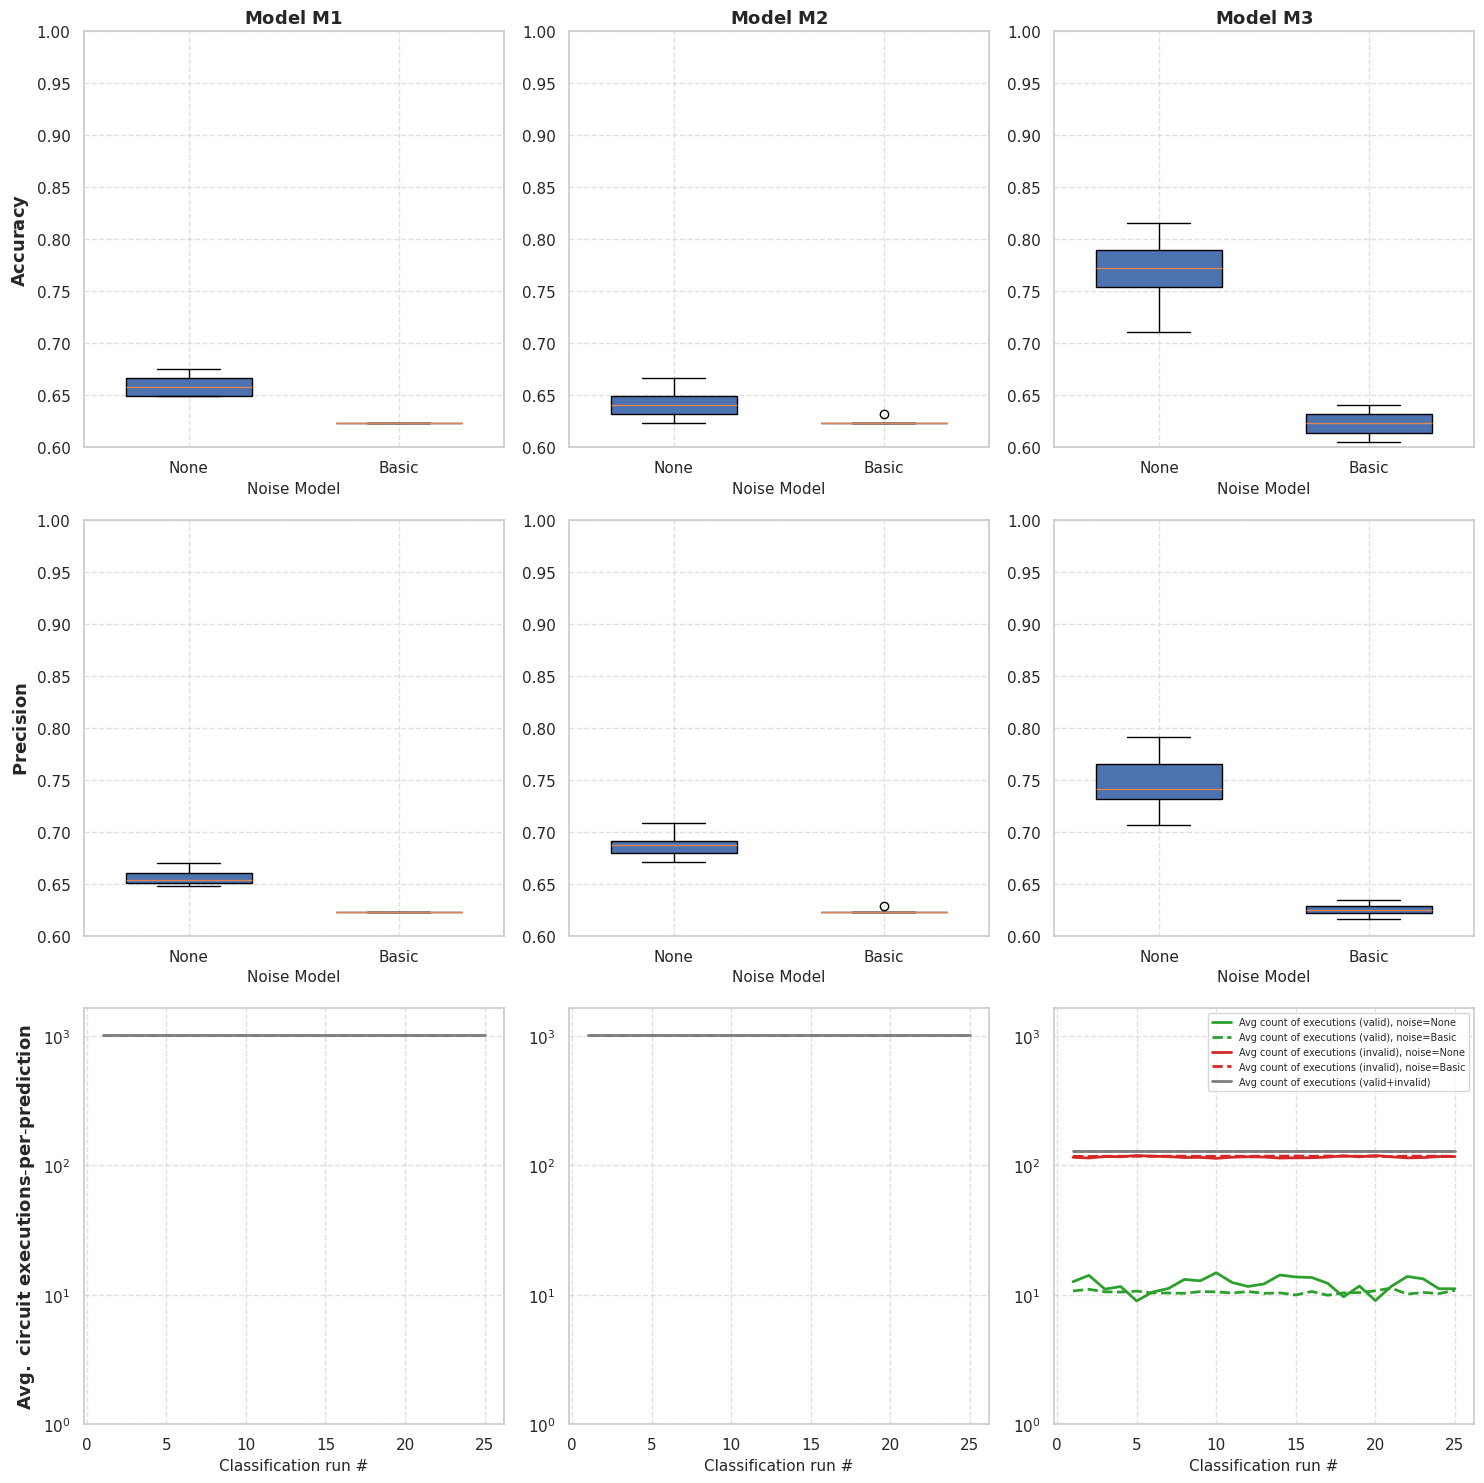

In [100]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

df = df_experiments.copy()

model_names = {
    #"X": "Many~shots~model,~default~strategy",
    "X": "Model~M1",
    #"Y": "Many~shots~model,~Hamming~strategy",
    "Y": "Model~M2",
    #"Z": "One~shot~model,~Hamming~strategy",
    "Z": "Model~M3"
}

metrics = ["Accuracy", "Precision"]
metric_colors = {"Accuracy": "tab:blue", "Precision": "tab:orange", "Recall": "tab:green"}
metric_2_colors = {"Avg number of valids": "tab:green", "Avg number of invalids": "tab:red", "Avg number of executions": "tab:gray"}


models = df["model"].unique()
noise_models = df["noise_model"].unique()
line_styles = ["-", "--", "-.", ":"]  # Different line styles for different noise models
noise_models_markers = {"None": "o", "Basic": "^"}

# Create a single figure with 2 rows, columns = number of models
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(models),
    figsize=(5 * len(models), 15),  # double height
    sharex=False,
    sharey=False
)

# Ensure axes is 2D array even if one model
if len(models) == 1:
    axes = axes.reshape(3, 1)

# -----------------------
# First row: Accuracy/Precision/Recall metrics
# -----------------------
for j, model in enumerate(models):
    ax = axes[0, j]

    metric = metrics[0]

    data_to_plot = []
    labels = []

    for noise_model in noise_models:
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        data_to_plot.append(subset[metric].values)
        labels.append(noise_model)

    # Create boxplots (2 per model if you have 2 noise models)
    ax.boxplot(
        data_to_plot,
        patch_artist=True,
        widths=0.6
    )

    ax.set_xticklabels(labels)
    #ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Noise Model", fontsize=11)
    #ax.set_ylabel(f"{metric}", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim([0.6, 1.0])

# -----------------------
# Second row: Min/Avg/Max number of executions (log scale)
# -----------------------
for j, model in enumerate(models):
    ax = axes[1, j]

    metric = metrics[1]

    data_to_plot = []
    labels = []

    for noise_model in noise_models:
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        data_to_plot.append(subset[metric].values)
        labels.append(noise_model)

    # Create boxplots (2 per model if you have 2 noise models)
    ax.boxplot(
        data_to_plot,
        patch_artist=True,
        widths=0.6
    )

    ax.set_xticklabels(labels)
    #ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Noise Model", fontsize=11)
    #ax.set_ylabel(f"{metric}", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim([0.6, 1.0])

# -----------------------
# Third row: Avg number of valid/invalid shots
# -----------------------
for j, model in enumerate(models):
    ax = axes[2, j]

    for k, noise_model in enumerate(noise_models):
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]

        if model == "Z":
            for metric in ["Avg number of valids", "Avg number of invalids"]:
                grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])
    
                ax.plot(
                    grouped.index,
                    grouped["mean"],
                    label=f"{metric}",
                    color=metric_2_colors[metric],
                    linestyle=line_styles[k % len(line_styles)],
                    linewidth=2
                )
                
        for metric in ["Avg number of executions"]:
            grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])

            ax.plot(
                grouped.index,
                grouped["mean"],
                label=f"Avg number of total executions (valid + invalid)",
                color=metric_2_colors[metric],
                linestyle=line_styles[k % len(line_styles)],
                linewidth=2
            )
    
    #ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Classification run #", fontsize=11)
    #ax.set_ylabel("executions-per-prediction", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_yscale("log")
    ax.set_ylim([1, 1628])

# -----------------------
# Legends
# -----------------------
legends = []
# First row legend (Boxplot version)
legend_handles = []

legend_handles.append( Patch(edgecolor="black", label=f"{metrics[0]}"))
legends.append(copy.deepcopy(legend_handles))

# Second row legend
legend_handles = []

legend_handles.append( Patch(edgecolor="black", label=f"{metrics[1]}"))
legends.append(copy.deepcopy(legend_handles))

# Third row legend
legend_handles = []
for metric in ["Avg number of valids"]:
    for k, noise_model in enumerate(noise_models):
        legend_handles.append(Line2D([0], [0], color=metric_2_colors[metric], lw=2,
                                     linestyle=line_styles[k % len(line_styles)], 
                                     label=f"{metric.split(' ')[0]} count of executions (valid), noise={noise_model}"))
for metric in ["Avg number of invalids"]:
    for k, noise_model in enumerate(noise_models):
        legend_handles.append(Line2D([0], [0], color=metric_2_colors[metric], lw=2,
                                     linestyle=line_styles[k % len(line_styles)], 
                                     label=f"{metric.split(' ')[0]} count of executions (invalid), noise={noise_model}"))

for metric in ["Avg number of executions"]:
    legend_handles.append(Line2D([0], [0], color=metric_2_colors[metric], lw=2,
                                 linestyle=line_styles[0 % len(line_styles)], 
                                 label=f"{metric.split(' ')[0]} count of executions (valid+invalid)"))
        
legends.append(copy.deepcopy(legend_handles))

#axes[0, 0].legend(handles=legends[0], fontsize=7, loc="best")
#axes[1, 0].legend(handles=legends[1], fontsize=7, loc="best")
axes[2, 2].legend(handles=legends[2], fontsize=7, loc="best")
axes[0, 0].set_title(r"$\bf{" + f"{model_names[models[0]]}" + "}$", fontsize=13)
axes[0, 1].set_title(r"$\bf{" + f"{model_names[models[1]]}" + "}$", fontsize=13)
axes[0, 2].set_title(r"$\bf{" + f"{model_names[models[2]]}" + "}$", fontsize=13)
axes[0, 0].set_ylabel(r"$\bf{"+metrics[0]+"}$", fontsize=13)
axes[1, 0].set_ylabel(r"$\bf{"+metrics[1]+"}$", fontsize=13)
axes[2, 0].set_ylabel(r"$\mathbf{Avg.~circuit~executions\text{-}per\text{-}prediction}$", fontsize=13)

plt.tight_layout()
plt.show()
if save_plot:
    plot_filename = f"{results_file.split('.')[0]}_3x3_boxplots.v{version}.png"
    if os.path.exists(f"./results/{plot_filename}"):
        print(f"⚠️ Warning: ./results/{plot_filename} already exists!")
    else:
        fig.savefig(f"./results/{plot_filename}", dpi=300, bbox_inches="tight")


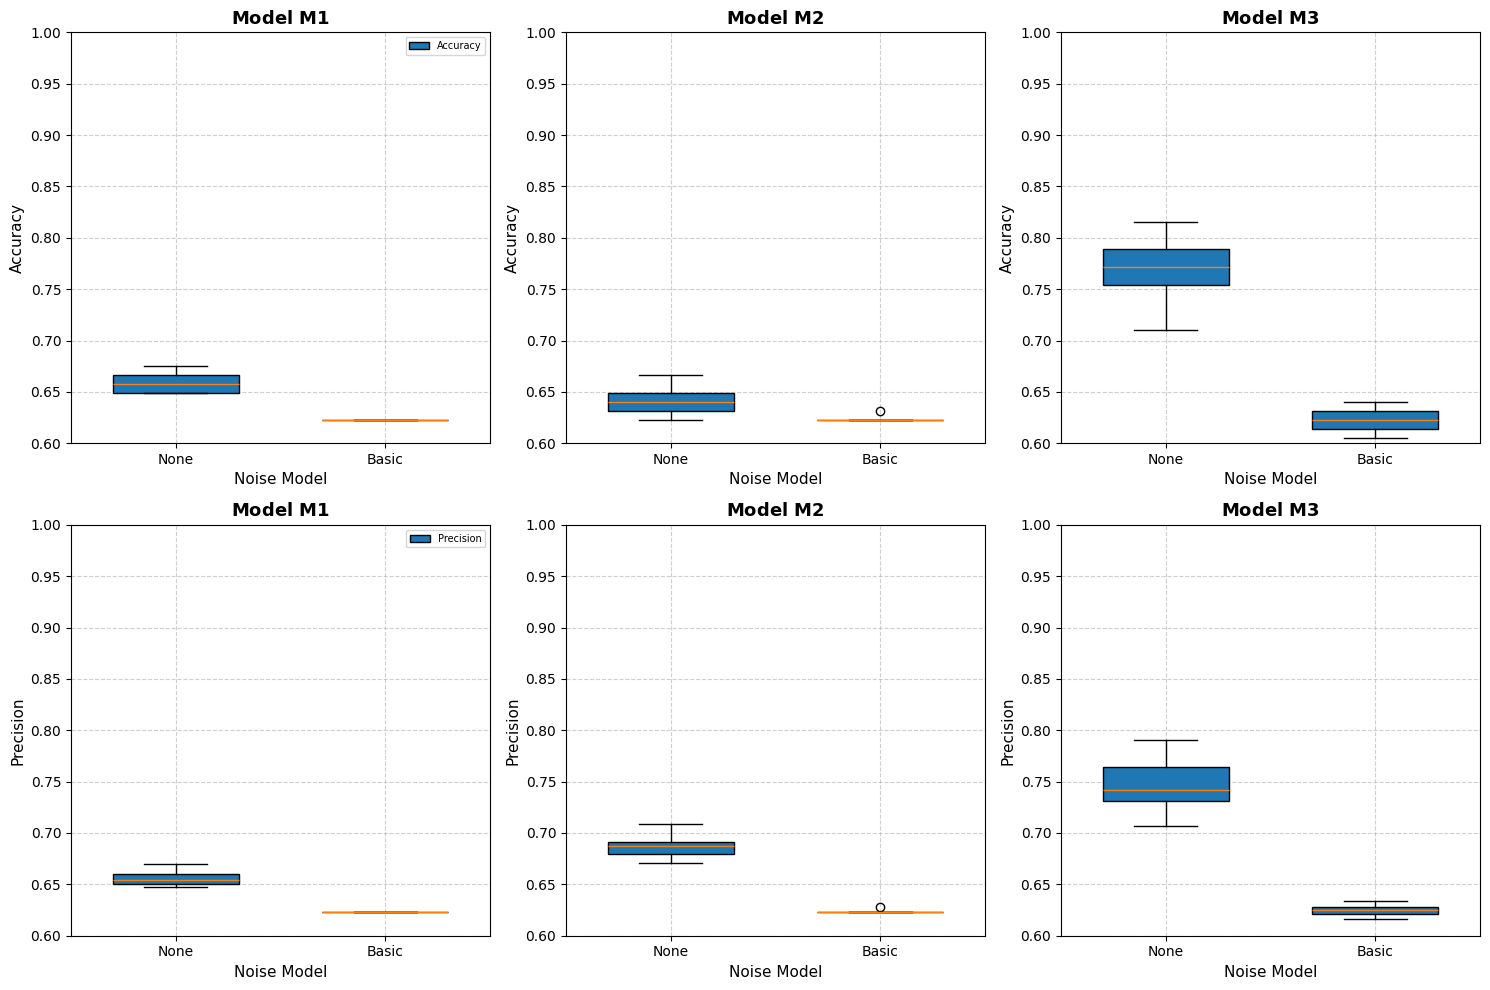

In [193]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = df_experiments.copy()

model_names = {
    #"X": "Many~shots~model,~default~strategy",
    "X": "Model~M1",
    #"Y": "Many~shots~model,~Hamming~strategy",
    "Y": "Model~M2",
    #"Z": "One~shot~model,~Hamming~strategy",
    "Z": "Model~M3"
}

metrics = ["Accuracy", "Precision"]
metric_colors = {"Accuracy": "tab:blue", "Precision": "tab:orange", "Recall": "tab:green"}
metric_2_colors = {"Avg number of valids": "tab:green", "Avg number of invalids": "tab:red"}


models = df["model"].unique()
noise_models = df["noise_model"].unique()
line_styles = ["-", "--", "-.", ":"]  # Different line styles for different noise models
noise_models_markers = {"None": "o", "Basic": "^"}

# Create a single figure with 2 rows, columns = number of models
fig, axes = plt.subplots(
    nrows=2,
    ncols=len(models),
    figsize=(5 * len(models), 10),  # double height
    sharex=False,
    sharey=False
)

# Ensure axes is 2D array even if one model
if len(models) == 1:
    axes = axes.reshape(2, 1)

# -----------------------
# First row: Accuracy/Precision/Recall metrics
# -----------------------
for j, model in enumerate(models):
    ax = axes[0, j]

    metric = metrics[0]

    data_to_plot = []
    labels = []

    for noise_model in noise_models:
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        data_to_plot.append(subset[metric].values)
        labels.append(noise_model)

    # Create boxplots (2 per model if you have 2 noise models)
    ax.boxplot(
        data_to_plot,
        patch_artist=True,
        widths=0.6
    )

    ax.set_xticklabels(labels)
    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Noise Model", fontsize=11)
    ax.set_ylabel(f"{metric}", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim([0.6, 1.0])

# -----------------------
# Second row: Min/Avg/Max number of executions (log scale)
# -----------------------
for j, model in enumerate(models):
    ax = axes[1, j]

    metric = metrics[1]

    data_to_plot = []
    labels = []

    for noise_model in noise_models:
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        data_to_plot.append(subset[metric].values)
        labels.append(noise_model)

    # Create boxplots (2 per model if you have 2 noise models)
    ax.boxplot(
        data_to_plot,
        patch_artist=True,
        widths=0.6
    )

    ax.set_xticklabels(labels)
    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Noise Model", fontsize=11)
    ax.set_ylabel(f"{metric}", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim([0.6, 1.0])

# -----------------------
# Legends
# -----------------------
legends = []
# First row legend (Boxplot version)
legend_handles = []

legend_handles.append( Patch(edgecolor="black", label=f"{metrics[0]}"))
legends.append(copy.deepcopy(legend_handles))

# Second row legend
legend_handles = []

legend_handles.append( Patch(edgecolor="black", label=f"{metrics[1]}"))
legends.append(copy.deepcopy(legend_handles))

axes[0, 0].legend(handles=legends[0], fontsize=7, loc="best")
axes[1, 0].legend(handles=legends[1], fontsize=7, loc="best")

plt.tight_layout()
plt.show()
if save_plot:
    plot_filename = f"{results_file.split('.')[0]}_2x3_boxplots.v{version}.png"
    if os.path.exists(f"./results/{plot_filename}"):
        print(f"⚠️ Warning: ./results/{plot_filename} already exists!")
    else:
        fig.savefig(f"./results/{plot_filename}", dpi=300, bbox_inches="tight")


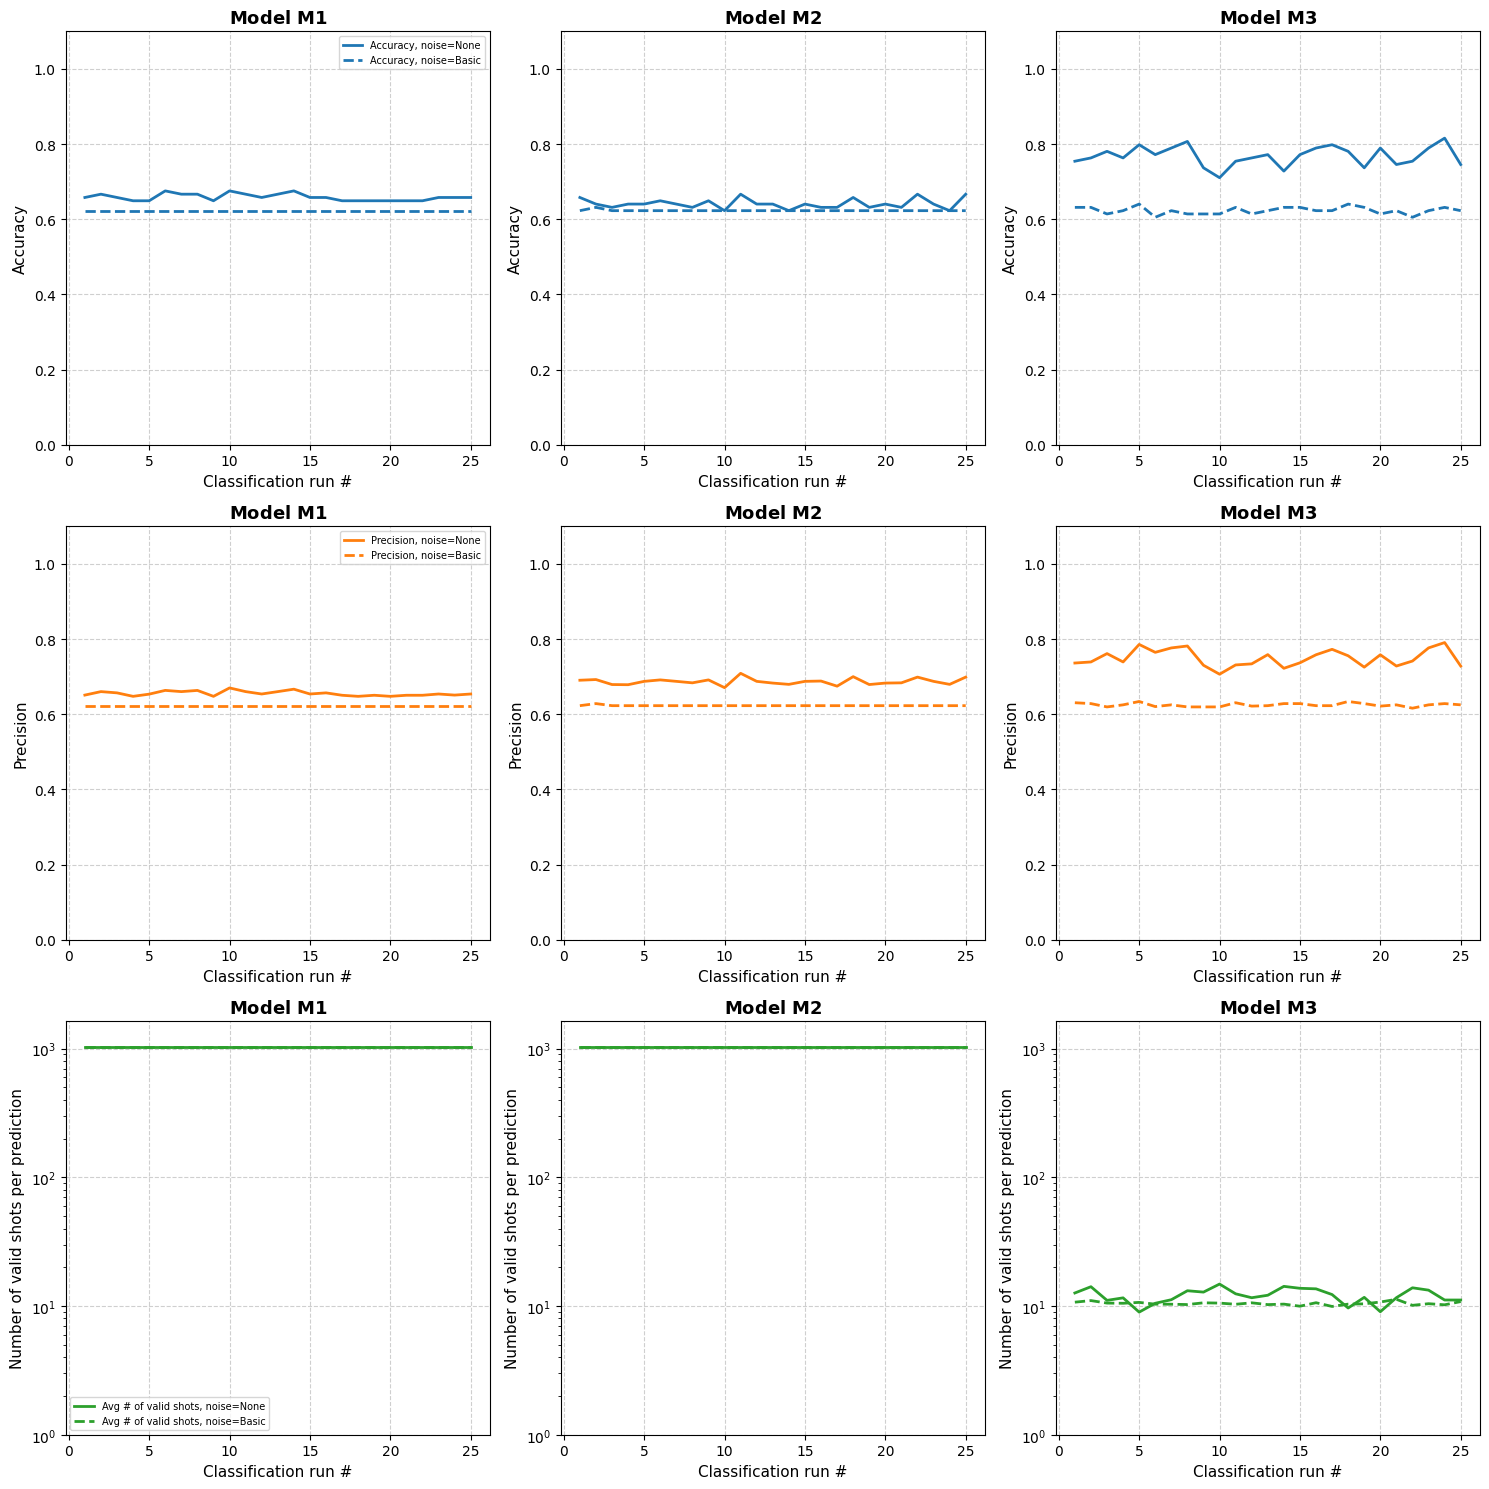

In [166]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = df_experiments.copy()

model_names = {
    #"X": "Many~shots~model,~default~strategy",
    "X": "Model~M1",
    #"Y": "Many~shots~model,~Hamming~strategy",
    "Y": "Model~M2",
    #"Z": "One~shot~model,~Hamming~strategy",
    "Z": "Model~M3"
}

metrics = ["Accuracy", "Precision"]
metric_colors = {"Accuracy": "tab:blue", "Precision": "tab:orange", "Recall": "tab:green"}
metric_2_colors = {"Avg number of valids": "tab:green", "Avg number of invalids": "tab:red"}


models = df["model"].unique()
noise_models = df["noise_model"].unique()
line_styles = ["-", "--", "-.", ":"]  # Different line styles for different noise models
noise_models_markers = {"None": "o", "Basic": "^"}

# Create a single figure with 2 rows, columns = number of models
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(models),
    figsize=(5 * len(models), 15),  # double height
    sharex=False,
    sharey=False
)

# Ensure axes is 2D array even if one model
if len(models) == 1:
    axes = axes.reshape(3, 1)

# -----------------------
# First row: Accuracy/Precision/Recall metrics
# -----------------------
for j, model in enumerate(models):
    ax = axes[0, j]
            
    for k, noise_model in enumerate(noise_models):
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        metric = metrics[0]
        
        grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])
        ax.plot(
            grouped.index,
            grouped["mean"],
            label=f"{metric} ({noise_model})",
            color=metric_colors[metric],
            linestyle=line_styles[k % len(line_styles)],
            linewidth=2
        )

    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Classification run #", fontsize=11)
    ax.set_ylabel(f"{metrics[0]}", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim([0.0, 1.1])

# -----------------------
# Second row: Min/Avg/Max number of executions (log scale)
# -----------------------
for j, model in enumerate(models):
    ax = axes[1, j]
            
    for k, noise_model in enumerate(noise_models):
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        metric = metrics[1]
        
        grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])
        ax.plot(
            grouped.index,
            grouped["mean"],
            label=f"{metric} ({noise_model})",
            color=metric_colors[metric],
            linestyle=line_styles[k % len(line_styles)],
            linewidth=2
        )

    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Classification run #", fontsize=11)
    ax.set_ylabel(f"{metrics[1]}", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim([0.0, 1.1])

# -----------------------
# Third row: Avg number of valid/invalid shots
# -----------------------
for j, model in enumerate(models):
    ax = axes[2, j]

    for k, noise_model in enumerate(noise_models):
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        for metric in ["Avg number of valids"]:
            #grouped = subset.groupby("iteration")["Max number of valids"].agg(["mean", "std"])
            grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])

            ax.plot(
                grouped.index,
                grouped["mean"],
                label=f"{metric}",
                color=metric_2_colors[metric],
                linestyle=line_styles[k % len(line_styles)],
                linewidth=2
            )
    
    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Classification run #", fontsize=11)
    ax.set_ylabel("Number of valid shots per prediction", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_yscale("log")
    ax.set_ylim([1, 1628])

# -----------------------
# Legends
# -----------------------
legends = []
# First row legend
legend_handles = []
for k, noise_model in enumerate(noise_models):
    legend_handles.append(Line2D([0], [0], color=metric_colors[metrics[0]], lw=2,
                                 linestyle=line_styles[k % len(line_styles)], 
                                 label=f"{metrics[0]}, noise={noise_model}"))
legends.append(copy.deepcopy(legend_handles))

# Second row legend
legend_handles = []
for k, noise_model in enumerate(noise_models):
        legend_handles.append(Line2D([0], [0], color=metric_colors[metrics[1]], lw=2,
                                     linestyle=line_styles[k % len(line_styles)], 
                                     label=f"{metrics[1]}, noise={noise_model}"))
legends.append(copy.deepcopy(legend_handles))

# Third row legend
legend_handles = []
for metric in ["Avg number of valids"]:
    for k, noise_model in enumerate(noise_models):
        legend_handles.append(Line2D([0], [0], color=metric_2_colors[metric], lw=2,
                                     linestyle=line_styles[k % len(line_styles)], 
                                     label=f"{metric.split(' ')[0]} # of valid shots, noise={noise_model}"))
legends.append(copy.deepcopy(legend_handles))

axes[0, 0].legend(handles=legends[0], fontsize=7, loc="best")
axes[1, 0].legend(handles=legends[1], fontsize=7, loc="best")
axes[2, 0].legend(handles=legends[2], fontsize=7, loc="best")

plt.tight_layout()
plt.show()
if save_plot:
    plot_filename = f"{results_file.split('.')[0]}_3x3.v{version}.png"
    if os.path.exists(f"./results/{plot_filename}"):
        print(f"⚠️ Warning: ./results/{plot_filename} already exists!")
    else:
        fig.savefig(f"./results/{plot_filename}", dpi=300, bbox_inches="tight")


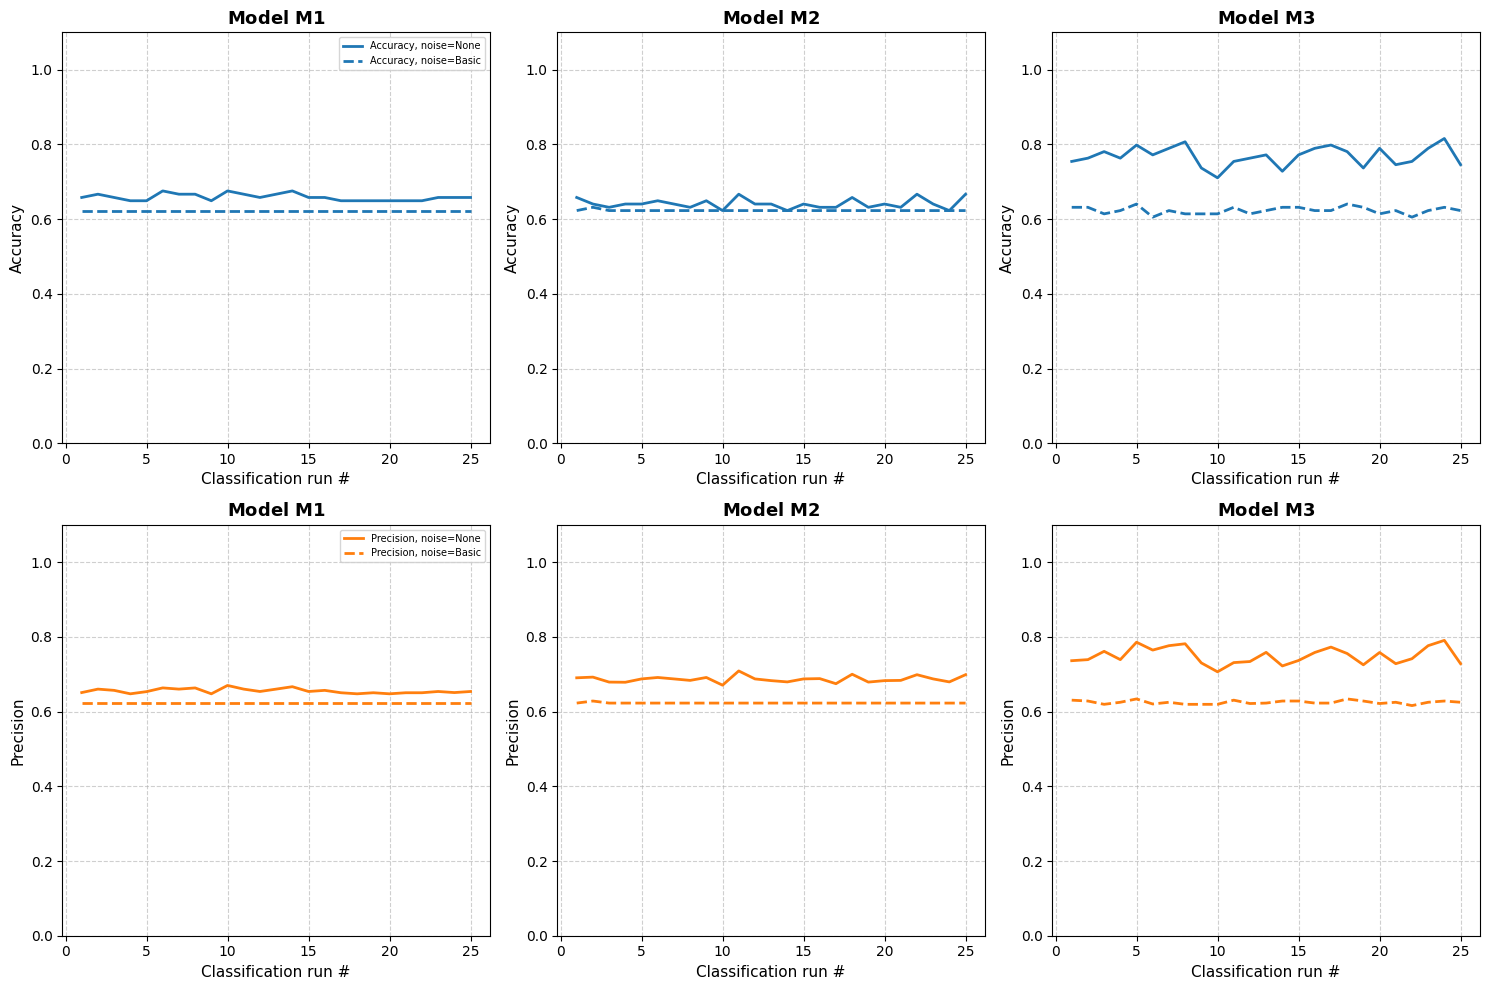

In [167]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = df_experiments.copy()

model_names = {
    #"X": "Many~shots~model,~default~strategy",
    "X": "Model~M1",
    #"Y": "Many~shots~model,~Hamming~strategy",
    "Y": "Model~M2",
    #"Z": "One~shot~model,~Hamming~strategy",
    "Z": "Model~M3"
}

metrics = ["Accuracy", "Precision"]
metric_colors = {"Accuracy": "tab:blue", "Precision": "tab:orange", "Recall": "tab:green"}
metric_2_colors = {"Avg number of valids": "tab:green", "Avg number of invalids": "tab:red"}


models = df["model"].unique()
noise_models = df["noise_model"].unique()
line_styles = ["-", "--", "-.", ":"]  # Different line styles for different noise models
noise_models_markers = {"None": "o", "Basic": "^"}

# Create a single figure with 2 rows, columns = number of models
fig, axes = plt.subplots(
    nrows=2,
    ncols=len(models),
    figsize=(5 * len(models), 10),  # double height
    sharex=False,
    sharey=False
)

# Ensure axes is 2D array even if one model
if len(models) == 1:
    axes = axes.reshape(2, 1)

# -----------------------
# First row: Accuracy/Precision/Recall metrics
# -----------------------
for j, model in enumerate(models):
    ax = axes[0, j]
            
    for k, noise_model in enumerate(noise_models):
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        metric = metrics[0]
        
        grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])
        ax.plot(
            grouped.index,
            grouped["mean"],
            label=f"{metric} ({noise_model})",
            color=metric_colors[metric],
            linestyle=line_styles[k % len(line_styles)],
            linewidth=2
        )

    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Classification run #", fontsize=11)
    ax.set_ylabel(f"{metrics[0]}", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim([0.0, 1.1])

# -----------------------
# Second row: Min/Avg/Max number of executions (log scale)
# -----------------------
for j, model in enumerate(models):
    ax = axes[1, j]
            
    for k, noise_model in enumerate(noise_models):
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        metric = metrics[1]
        
        grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])
        ax.plot(
            grouped.index,
            grouped["mean"],
            label=f"{metric} ({noise_model})",
            color=metric_colors[metric],
            linestyle=line_styles[k % len(line_styles)],
            linewidth=2
        )

    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Classification run #", fontsize=11)
    ax.set_ylabel(f"{metrics[1]}", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim([0.0, 1.1])

# -----------------------
# Legends
# -----------------------
legends = []
# First row legend
legend_handles = []
for k, noise_model in enumerate(noise_models):
    legend_handles.append(Line2D([0], [0], color=metric_colors[metrics[0]], lw=2,
                                 linestyle=line_styles[k % len(line_styles)], 
                                 label=f"{metrics[0]}, noise={noise_model}"))
legends.append(copy.deepcopy(legend_handles))

# Second row legend
legend_handles = []
for k, noise_model in enumerate(noise_models):
        legend_handles.append(Line2D([0], [0], color=metric_colors[metrics[1]], lw=2,
                                     linestyle=line_styles[k % len(line_styles)], 
                                     label=f"{metrics[1]}, noise={noise_model}"))
legends.append(copy.deepcopy(legend_handles))

axes[0, 0].legend(handles=legends[0], fontsize=7, loc="best")
axes[1, 0].legend(handles=legends[1], fontsize=7, loc="best")

plt.tight_layout()
plt.show()
if save_plot:
    plot_filename = f"{results_file.split('.')[0]}_2x3.v{version}.png"
    if os.path.exists(f"./results/{plot_filename}"):
        print(f"⚠️ Warning: ./results/{plot_filename} already exists!")
    else:
        fig.savefig(f"./results/{plot_filename}", dpi=300, bbox_inches="tight")


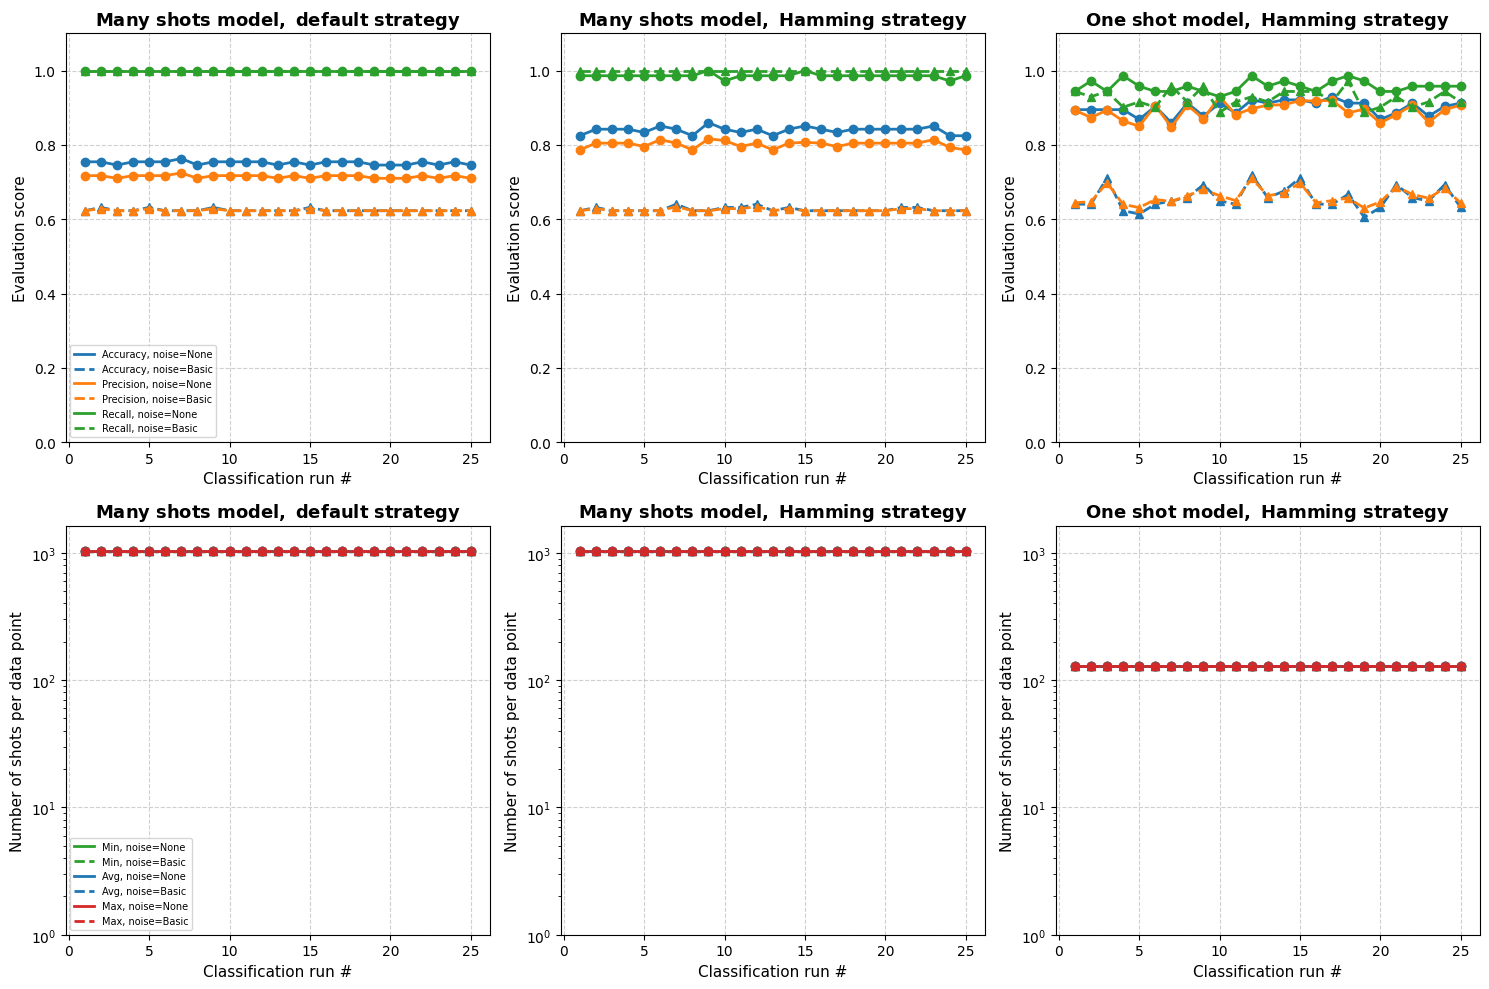

In [57]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = df_experiments.copy()

model_names = {
    "X": "Many~shots~model,~default~strategy",
    "Y": "Many~shots~model,~Hamming~strategy",
    "Z": "One~shot~model,~Hamming~strategy"
}

metrics = ["Accuracy", "Precision", "Recall"]
metric_colors = {"Accuracy": "tab:blue", "Precision": "tab:orange", "Recall": "tab:green"}
metric_2_colors = {"Min number of executions": "tab:green", "Avg number of executions": "tab:blue", "Max number of executions": "tab:red"}

models = df["model"].unique()
noise_models = df["noise_model"].unique()
line_styles = ["-", "--", "-.", ":"]  # Different line styles for different noise models
shot_colors = {"Avg": "tab:blue", "Max": "tab:red", "Min": "tab:green"}
noise_models_markers = {"None": "o", "Basic": "^"}

# Create a single figure with 2 rows, columns = number of models
fig, axes = plt.subplots(
    nrows=2,
    ncols=len(models),
    figsize=(5 * len(models), 10),  # double height
    sharex=False,
    sharey=False
)

# Ensure axes is 2D array even if one model
if len(models) == 1:
    axes = axes.reshape(2, 1)

# -----------------------
# First row: Accuracy/Precision/Recall metrics
# -----------------------
for j, model in enumerate(models):
    ax = axes[0, j]

    for k, noise_model in enumerate(noise_models):
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        for metric in metrics:
            grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])
            ax.plot(
                grouped.index,
                grouped["mean"],
                label=f"{metric} ({noise_model})",
                color=metric_colors[metric],
                linestyle=line_styles[k % len(line_styles)],
                marker=noise_models_markers[noise_model],
                linewidth=2
            )

    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Classification run #", fontsize=11)
    ax.set_ylabel("Evaluation score", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim([0.0, 1.1])

# -----------------------
# Second row: Min/Avg/Max number of executions (log scale)
# -----------------------
for j, model in enumerate(models):
    ax = axes[1, j]

    for k, noise_model in enumerate(noise_models):
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        for metric in ["Min number of executions", "Avg number of executions", "Max number of executions"]:
            grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])
            ax.plot(
                grouped.index,
                grouped["mean"],
                label=f"{metric}",
                color=metric_2_colors[metric],
                linestyle=line_styles[k % len(line_styles)],
                marker=noise_models_markers[noise_model],
                linewidth=2
            )
            
        #ax.plot(subset["Min number of executions"], marker=noise_models_markers[noise_model], linestyle='--', color='tab:green', label='Min repetitions')
        #ax.plot(subset["Avg number of executions"], marker=noise_models_markers[noise_model], linestyle='--', color='tab:blue', label='Avg repetitions')
        #ax.plot(subset["Max number of executions"], marker=noise_models_markers[noise_model], linestyle='--', color='tab:red', label='Max repetitions')
    
    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Classification run #", fontsize=11)
    ax.set_ylabel("Number of shots per data point", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_yscale("log")
    ax.set_ylim([1, 1628])

# -----------------------
# Legends
# -----------------------
# First row legend
legend_handles = []
for metric in metrics:
    for k, noise_model in enumerate(noise_models):
        legend_handles.append(Line2D([0], [0], color=metric_colors[metric], lw=2,
                                     linestyle=line_styles[k % len(line_styles)], 
                                     label=f"{metric}, noise={noise_model}"))
axes[0, 0].legend(handles=legend_handles, fontsize=7, loc="best")

# Second row legend
legend_handles = []
for stat_type in ["Min", "Avg", "Max"]:
    for k, noise_model in enumerate(noise_models):
        legend_handles.append(Line2D([0], [0], color=shot_colors[stat_type], lw=2,
                                     linestyle=line_styles[k % len(line_styles)], 
                                     label=f"{stat_type}, noise={noise_model}"))
axes[1, 0].legend(handles=legend_handles, fontsize=7, loc="best")

plt.tight_layout()
plt.show()
if save_plot:
    plot_filename = f"{results_file.split('.')[0]}.v{version}.png"
    if os.path.exists(f"./results/{plot_filename}"):
        print(f"⚠️ Warning: ./results/{plot_filename} already exists!")
    else:
        fig.savefig(f"./results/{plot_filename}", dpi=300, bbox_inches="tight")


In [ ]:
# TODO: show difference between accuracy loss - can be interesting for one shot vs others. 

### Statistical analysis

In [141]:
loaded_df_experiments = df_experiments.copy()

In [43]:
# 5 qubits
df_experiments_5_q = loaded_df_experiments.copy()

In [106]:
# noiseless
print(f"Noiseless:")
print(f"Model M1:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "None") & (df_experiments_5_q["model"] == "X"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())
print(f"Model M2:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "None") & (df_experiments_5_q["model"] == "Y"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())
print(f"Model M3:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "None") & (df_experiments_5_q["model"] == "Z"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())

# noise
print(f"\nNoise:")
print(f"Model M1:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "Basic") & (df_experiments_5_q["model"] == "X"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())
print(f"Model M2:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "Basic") & (df_experiments_5_q["model"] == "Y"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())
print(f"Model M3:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "Basic") & (df_experiments_5_q["model"] == "Z"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())

Noiseless:
Model M1:
 Accuracy                       0.658596
Precision                      0.655246
Recall                         0.953803
F1                             0.776787
ROC AUC                        0.782090
Avg number of executions    1024.000000
Avg number of valids        1024.000000
dtype: float64
Model M2:
 Accuracy                       0.641404
Precision                      0.686868
Recall                         0.779718
F1                             0.730253
ROC AUC                        0.669473
Avg number of executions    1024.000000
Avg number of valids        1024.000000
dtype: float64
Model M3:
 Accuracy                      0.768421
Precision                     0.749578
Recall                        0.944789
F1                            0.835704
ROC AUC                       0.853076
Avg number of executions    128.000000
Avg number of valids         12.084912
dtype: float64

Noise:
Model M1:
 Accuracy                       0.622807
Precision          

In [107]:
print(0.838246 - 0.628421)
print(0.625263 - 0.575789)

0.20982500000000004
0.04947400000000002


In [46]:
# 3 qubits
df_experiments_3_q = loaded_df_experiments.copy()

In [107]:
# noiseless
print(f"Noiseless:")
print(f"Model M1:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "None") & (df_experiments_3_q["model"] == "X"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())
print(f"Model M2:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "None") & (df_experiments_3_q["model"] == "Y"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())
print(f"Model M3:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "None") & (df_experiments_3_q["model"] == "Z"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())

# noise
print(f"\nNoise:")
print(f"Model M1:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "Basic") & (df_experiments_3_q["model"] == "X"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())
print(f"Model M2:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "Basic") & (df_experiments_3_q["model"] == "Y"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())
print(f"Model M3:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "Basic") & (df_experiments_3_q["model"] == "Z"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions", "Avg number of valids"]].mean())

Noiseless:
Model M1:
 Accuracy                       0.751579
Precision                      0.714883
Recall                         1.000000
F1                             0.833733
ROC AUC                        0.905804
Avg number of executions    1024.000000
Avg number of valids        1024.000000
dtype: float64
Model M2:
 Accuracy                       0.839298
Precision                      0.801732
Recall                         0.985915
F1                             0.884308
ROC AUC                        0.971182
Avg number of executions    1024.000000
Avg number of valids        1024.000000
dtype: float64
Model M3:
 Accuracy                      0.900000
Precision                     0.891041
Recall                        0.957183
F1                            0.922718
ROC AUC                       0.953770
Avg number of executions    128.000000
Avg number of valids         21.975789
dtype: float64

Noise:
Model M1:
 Accuracy                       0.624211
Precision          

In [79]:
0.822456-0.760000

0.062455999999999956

In [106]:
(1024 * 114)/(3.69 * 114)

277.5067750677507

In [87]:
82.25 - 62.32 

19.93

In [98]:
 0.760000 - 0.551228

0.20877199999999996

In [99]:
0.623158 - 0.551228

0.07192999999999994